<a href="https://colab.research.google.com/github/Raijeku/quantum-eigengame/blob/main/EigenGame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.2 MB/s eta 0:00:00


In [ ]:
!pip install pennylane-qulacs["cpu"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 944.4/944.4 kB 4.7 MB/s eta 0:00:00


In [ ]:
import autograd.numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import qaoa
from pennylane import numpy as np
from scipy.linalg import expm, sqrtm, eigh
import networkx as nx
from jax import grad
import jax.numpy as jnp
import numpy

np.random.seed(0)

# Relevant test

In [ ]:
from jax import vjp

def generate_matrix(eigenvalues):
  D = np.diag(eigenvalues)
  P = np.random.rand(D.shape[0], D.shape[0])
  norm = np.linalg.norm(P)
  P = P/norm
  np.fill_diagonal(P, 1)
  return np.dot(P, np.dot(D, np.linalg.inv(P))), P

# Variational functions

def U3(theta_3):
  return jnp.array([[jnp.cos(theta_3[0]/2), -jnp.exp(1j*theta_3[2])*jnp.sin(theta_3[0]/2)],
                   [jnp.exp(1j*theta_3[1])*jnp.sin(theta_3[0]/2), jnp.exp(1j*(theta_3[1]+theta_3[2]))*jnp.cos(theta_3[0]/2)]])

def ansatz(theta):
  qubits, layers = theta.shape[:2]
  n = 2**qubits

  U = jnp.eye(n)
  for l in range(layers):
    U_l = U3(theta[0,l])
    for k in range(1, qubits):
      U_l = jnp.kron(U_l, U3(theta[k, l]))
    U = jnp.matmul(U, U_l)

  return U

def v(theta_index):
  qubits = theta_index.shape[0]
  n = 2**qubits

  s = jnp.ones(n)
  s /= jnp.linalg.norm(s)

  phi = jnp.matmul(ansatz(theta_index), s)

  return phi

def d_v(theta_index):
  return grad(v)(theta_index)

def rewards_var(theta_i, X):
  return jnp.linalg.norm(X @ v(theta_i))**2

def penalties_var(theta_i, X, thetas=[]):
  return jnp.array([(jnp.conj(X @ v(theta_i)) @ X @ v(theta_j))**2 / (jnp.linalg.norm(X @ v(theta_i)))**2 for theta_j in thetas]).sum(axis=0)

def agent_utility_var(theta_i, X, thetas=[]):
  return rewards_var(theta_i, X) - penalties_var(theta_i, X, thetas)

def d_rewards_var(theta_i, X):
  return grad(rewards_var)(theta_i, X)

def d_penalties_var(theta_i, X, thetas=[]):
  if len(thetas) == 0:
    return grad(penalties_var)(theta_i, X, thetas)
  else:
    return grad(penalties_var, holomorphic = True)(theta_i, X, thetas)

def d_agent_utility_var(theta_i, X, thetas=[]):
  return d_rewards_var(theta_i, X) - d_penalties_var(theta_i, X, thetas)

# Variational tests

qubits = 3
layers = 2
n = 2**qubits

# Using U3 gates
theta_init = np.random.rand(qubits, layers, 3)

eigs = np.random.rand(n)
X, _ = generate_matrix(eigs)

print(agent_utility_var(theta_init, X))

print(d_agent_utility_var(theta_init, X), d_agent_utility_var(theta_init, X).shape)

# Normal functions

def rewards(v_i, X):
  return jnp.linalg.norm(X @ v_i)**2

def penalties(v_i, X, v=[]):
  return jnp.array([(jnp.conj(X @ v_i) @ X @ v_j)**2 / (jnp.linalg.norm(X @ v_i))**2 for v_j in v]).sum(axis=0)

def agent_utility(v_i, X, v=[]):
  return rewards(v_i, X) - penalties(v_i, X, v)

def d_rewards(v_i, X):
  return grad(rewards)(v_i, X)

def d_penalties(v_i, X, v=[]):
  if len(v) == 0:
    return grad(penalties)(v_i, X, v)
  else:
    return grad(penalties, holomorphic = True)(v_i, X, v)

def d_agent_utility(v_i, X, v=[]):
  return d_rewards(v_i, X) - d_penalties(v_i, X, v)

# Normal tests

0.33621892
[[[ 0.040738   -0.00074055 -0.03288677]
  [ 0.07105256 -0.0328868  -0.06959726]]

 [[-0.01039018 -0.00031603  0.00765458]
  [-0.04409687  0.00765458  0.00886972]]

 [[ 0.03207656  0.00082206  0.06352656]
  [-0.02758132  0.06352656  0.14963204]]] (3, 2, 3)


# $U1(\theta)$ ansatz gradient verification

In [ ]:
import jax.numpy as jnp

## 1 qubit at depth 1

In [ ]:
Z = np.array([[1, 0], [0, -1]])
s = np.ones(2)
s /= np.linalg.norm(s)
Z, s

def U1(theta):
  return jnp.array([[1, 0], [0, jnp.exp(theta*1j)]])

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_k)]])

def grad_U1(theta):
  return 2 * np.conjugate(s @ U1(theta)).T @ Z @ A(theta) @ s

print(U1(0))
print(circuit_U1(0))

[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
0j


In [ ]:
theta = 0. + 0j

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array(0.-0.99999994j, dtype=complex64, weak_type=True)

In [ ]:
grad_U1(theta)

Array(0.-0.99999994j, dtype=complex64)

## q qubit at depth 1

In [ ]:
qubits = 3
Z = np.array([[1, 0], [0, -1]])
for i in range(qubits-1):
  Z = np.kron(Z, np.array([[1, 0], [0, -1]]) )
s = np.ones(2**qubits)
s /= np.linalg.norm(s)
print(Z, s)

def U1(theta):
  U1 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, qubits):
    U1 = jnp.kron(U1, jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]]))
  return U1

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_k)]])

def grad_U1(theta):

  grad_inner = []

  grad_inner_0 = A(theta[0])
  for i in range(1, qubits):
    grad_inner_0 = jnp.kron(grad_inner_0, jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]]))
  grad_inner.append(grad_inner_0)

  U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, len(theta)):
    grad = U1_0
    for j in range(1, i):
      grad = jnp.kron(grad, np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]]))
    grad = jnp.kron(grad, A(theta[i]))
    for j in range(i+1, qubits):
      grad = jnp.kron(grad, np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]]))
    grad_inner.append(grad)

  return jnp.array([2 * jnp.conjugate(s @ U1(theta)).T @ Z @ grad_i @ s for grad_i in grad_inner])

print(U1(np.array([0, 0, 0])))
print(circuit_U1(np.array([0, 0, 0])))

[[ 1  0  0  0  0  0  0  0]
 [ 0 -1  0  0  0  0  0  0]
 [ 0  0 -1  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0]
 [ 0  0  0  0 -1  0  0  0]
 [ 0  0  0  0  0  1  0  0]
 [ 0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0 -1]] [0.35355339 0.35355339 0.35355339 0.35355339 0.35355339 0.35355339
 0.35355339 0.35355339]
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]
0j


In [ ]:
theta = np.ones(qubits) + 1j*np.zeros(qubits)

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array([ 5.7372224e-10+1.6650121e-08j,  5.7372224e-10+1.6650121e-08j,
       -1.7026657e-08+2.8641157e-08j], dtype=complex64)

In [ ]:
grad_U1(theta)

Array([ 5.8855354e-10+1.4901161e-08j,  5.8855354e-10+1.4901161e-08j,
       -3.0994556e-09+1.4901161e-08j], dtype=complex64)

## 1 qubit at depth p

In [ ]:
qubits = 1
depth = 3
Z = np.array([[1, 0], [0, -1]])
s = np.ones(2**qubits)
s /= np.linalg.norm(s)
print(Z, s)

def U1(theta):
  U1 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, depth):
    U1 = U1 @ jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]])
  return U1

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_k)]])

def grad_U1(theta):

  grad_inner = []

  grad_inner_0 = A(theta[0])
  for i in range(1, depth):
    grad_inner_0 = grad_inner_0 @ jnp.array([[1, 0], [0, jnp.exp(theta[i]*1j)]])
  grad_inner.append(grad_inner_0)

  U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0]*1j)]])
  for i in range(1, len(theta)):
    grad = U1_0
    for j in range(1, i):
      grad = grad @ np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]])
    grad = grad @ A(theta[i])
    for j in range(i+1, depth):
      grad = grad @ np.array([[1, 0], [0, jnp.exp(theta[j]*1j)]])
    grad_inner.append(grad)

  return jnp.array([2 * jnp.conjugate(s @ U1(theta)).T @ Z @ grad_i @ s for grad_i in grad_inner])

print(U1(np.array([0, 0, 0])))
print(circuit_U1(np.array([0, 0, 0])))

[[ 1  0]
 [ 0 -1]] [0.70710678 0.70710678]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
0j


In [ ]:
theta = np.ones(depth) + 1j*np.zeros(depth)

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array([ 4.6761670e-09-0.99999976j,  4.6761670e-09-0.99999976j,
       -2.5126155e-08-0.99999976j], dtype=complex64)

In [ ]:
grad_U1(theta)

Array([-4.3692885e-09-0.9999997j, -4.3692885e-09-0.9999997j,
       -4.3692885e-09-0.9999997j], dtype=complex64)

## q qubit at depth p

In [ ]:
qubits = 3
depth = 3
Z = np.array([[1, 0], [0, -1]])
for i in range(qubits-1):
  Z = np.kron(Z, np.array([[1, 0], [0, -1]]) )
s = np.ones(2**qubits)
s /= np.linalg.norm(s)
print(Z, s)

def U1(theta):
  U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
  U1 = U1_0
  for i in range(1, qubits):
    U1 = jnp.kron(U1, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
  for i in range(1, depth):
    U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
    for j in range(1, qubits):
      U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
    U1 = U1 @ U1_i
  return U1

def circuit_U1(theta):
  return jnp.conjugate(s @ U1(theta)).T @ Z @ U1(theta) @ s

def A(theta_l_k):
  return jnp.array([[0, 0], [0, 1j*jnp.exp(1j*theta_l_k)]])

def grad_U1(theta):

  grad_inner = []

  grad_inner_row = []

  # depth 0 qubit 0
  grad_inner_0 = A(theta[0, 0])
  for i in range(1, qubits):
    grad_inner_0 = jnp.kron(grad_inner_0, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
  for i in range(1, depth):
    grad_inner_0_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
    for j in range(1, qubits):
      grad_inner_0_i = jnp.kron(grad_inner_0_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
    grad_inner_0 = grad_inner_0 @ grad_inner_0_i
  grad_inner_row.append(grad_inner_0)

  # depth 0 qubit i>0
  for i in range(1, qubits):
    U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
    grad = U1_0
    for j in range(1, i):
      grad = jnp.kron(grad, jnp.array([[1, 0], [0, jnp.exp(theta[0, j]*1j)]]))
    grad = jnp.kron(grad, A(theta[0, i]))
    for j in range(i+1, qubits):
      grad = jnp.kron(grad, jnp.array([[1, 0], [0, jnp.exp(theta[0, j]*1j)]]))
    for i in range(1, depth):
      U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
      for j in range(1, qubits):
        U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
      grad = grad @ U1_i
    grad_inner_row.append(grad)

  grad_inner.append(grad_inner_row)

  # depth p>0 qubit q
  for l in range(1, depth):
    grad_inner_row = []

    # depth p>0 qubit 0
    U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
    for i in range(1, qubits):
      U1_0 = jnp.kron(U1_0, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
    grad = U1_0
    for i in range(1, l):
      U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
      for j in range(1, qubits):
        U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
      grad = grad @ U1_i

    U1_l = A(theta[l, 0])
    for i in range(1, qubits):
      U1_l = jnp.kron(U1_l, jnp.array([[1, 0], [0, jnp.exp(theta[l, i]*1j)]]))
    grad = grad @ U1_l

    for i in range(l+1, depth):
      U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
      for j in range(1, qubits):
        U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
      grad = grad @ U1_i
    grad_inner_row.append(grad)

    # depth p>0 qubit q>0
    for k in range(1, qubits):

      U1_0 = jnp.array([[1, 0], [0, jnp.exp(theta[0, 0]*1j)]])
      for i in range(1, qubits):
        U1_0 = jnp.kron(U1_0, jnp.array([[1, 0], [0, jnp.exp(theta[0, i]*1j)]]))
      grad = U1_0

      for i in range(1, l):
        U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
        for j in range(1, qubits):
          U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
        grad = grad @ U1_i

      U1_l = jnp.array([[1, 0], [0, jnp.exp(theta[l, 0]*1j)]])
      for i in range(1, k):
        U1_l = jnp.kron(U1_l, jnp.array([[1, 0], [0, jnp.exp(theta[l, i]*1j)]]))
      U1_l = jnp.kron(U1_l, A(theta[l, k]))
      for i in range(k+1, qubits):
        U1_l = jnp.kron(U1_l, jnp.array([[1, 0], [0, jnp.exp(theta[l, i]*1j)]]))
      grad = grad @ U1_l

      for i in range(l+1, depth):
        U1_i = jnp.array([[1, 0], [0, jnp.exp(theta[i, 0]*1j)]])
        for j in range(1, qubits):
          U1_i = jnp.kron(U1_i, jnp.array([[1, 0], [0, jnp.exp(theta[i, j]*1j)]]))
        grad = grad @ U1_i
      grad_inner_row.append(grad)

    grad_inner.append(grad_inner_row)

  return jnp.array([[2 * jnp.conjugate(s @ U1(theta)).T @ Z @ grad_i_j @ s for grad_i_j in grad_inner_i] for grad_inner_i in grad_inner ])

print(U1(np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])))
print(circuit_U1(np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]])))

[[ 1  0  0  0  0  0  0  0]
 [ 0 -1  0  0  0  0  0  0]
 [ 0  0 -1  0  0  0  0  0]
 [ 0  0  0  1  0  0  0  0]
 [ 0  0  0  0 -1  0  0  0]
 [ 0  0  0  0  0  1  0  0]
 [ 0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0 -1]] [0.35355339 0.35355339 0.35355339 0.35355339 0.35355339 0.35355339
 0.35355339 0.35355339]
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]
0j


In [ ]:
theta = np.zeros((depth, qubits)) + 1j*np.ones((depth, qubits))

grad_func = grad(circuit_U1, holomorphic=True)(theta)
grad_func

Array([[0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j]], dtype=complex64)

In [ ]:
grad_U1(theta)

Array([[0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j],
       [0.-0.00061662j, 0.-0.00061662j, 0.-0.00061662j]], dtype=complex64)

# Testing swap-test

In [ ]:
coeffs = np.array([0.5, 0.25, 0.4, 0.75, 1])
obs = [qml.PauliX(0) @ qml.PauliZ(1) @ qml.PauliX(2), \
       qml.Identity(0) @ qml.PauliX(1) @ qml.PauliX(2), \
       qml.PauliZ(0) @ qml.PauliX(1) @ qml.Identity(2), \
       qml.PauliZ(0) @ qml.PauliZ(1) @ qml.PauliX(2), \
       qml.PauliX(0) @ qml.PauliX(1) @ qml.PauliZ(2)]


H = qml.Hamiltonian(-coeffs, obs)
H_P = qml.Hamiltonian(coeffs, obs)

H_P_matrix = qml.matrix(H_P)
H_matrix = qml.matrix(H)

In [ ]:
np.linalg.eig(H_P_matrix)

EigResult(eigenvalues=array([ 1.76930639+0.j,  0.96930639+0.j, -1.76930639+0.j, -0.96930639+0.j,
       -1.76930639+0.j, -0.96930639+0.j,  1.76930639+0.j,  0.96930639+0.j]), eigenvectors=tensor([[ 4.86930476e-01+0.j,  5.23014758e-01-0.j, -5.12736494e-01+0.j,
         -4.75873474e-01-0.j,  3.48941223e-03+0.j,  9.60498411e-02+0.j,
          3.70127748e-02-0.j,  2.38503314e-01-0.j],
        [ 3.11373564e-01-0.j,  2.82580442e-01-0.j,  1.17663138e-01+0.j,
          5.02404205e-01+0.j,  4.28794395e-01+0.j, -3.98101991e-01+0.j,
          4.74732513e-01-0.j, -1.16439307e-01-0.j],
        [ 3.80971104e-01-0.j, -2.52914117e-01-0.j,  3.61796836e-01+0.j,
         -2.77968457e-01-0.j,  3.23420326e-01+0.j,  4.90019399e-01+0.j,
          3.71127109e-01-0.j,  2.43414914e-01-0.j],
        [-3.74949187e-01-0.j,  5.23620557e-01+0.j,  5.34117002e-01+0.j,
         -3.83661195e-01-0.j, -1.31357740e-01+0.j,  1.68404343e-01+0.j,
          2.11257810e-01-0.j,  3.31652213e-03-0.j],
        [ 7.21676004e-17-0.j,

In [ ]:
a = np.random.rand(8)
a /= np.linalg.norm(a)
b = np.random.rand(8)
b /= np.linalg.norm(b)

print('a',a)
print('b',b)
print('H',H_matrix)
print('e^-iH', np.exp(-1j*H_matrix))
print(a @ H_matrix @ b)
print(a @ np.exp(-1j*H_matrix) @ b)
res = a @ H_matrix @ b
res_exp = a @ np.exp(-1j*H_matrix) @ b

a [0.31392474 0.40909277 0.3447844  0.31167657 0.24233318 0.36945545
 0.25030261 0.5100997 ]
b [0.5408825  0.21521721 0.44437768 0.29685697 0.3188308  0.51951683
 0.03987096 0.04890374]
H [[ 0.  +0.j -0.75+0.j -0.4 +0.j -0.25+0.j  0.  +0.j -0.5 +0.j -1.  +0.j
   0.  +0.j]
 [-0.75+0.j  0.  +0.j -0.25+0.j -0.4 +0.j -0.5 +0.j  0.  +0.j  0.  +0.j
   1.  +0.j]
 [-0.4 +0.j -0.25+0.j  0.  +0.j  0.75+0.j -1.  +0.j  0.  +0.j  0.  +0.j
   0.5 +0.j]
 [-0.25+0.j -0.4 +0.j  0.75+0.j  0.  +0.j  0.  +0.j  1.  +0.j  0.5 +0.j
   0.  +0.j]
 [ 0.  +0.j -0.5 +0.j -1.  +0.j  0.  +0.j  0.  +0.j  0.75+0.j  0.4 +0.j
  -0.25+0.j]
 [-0.5 +0.j  0.  +0.j  0.  +0.j  1.  +0.j  0.75+0.j  0.  +0.j -0.25+0.j
   0.4 +0.j]
 [-1.  +0.j  0.  +0.j  0.  +0.j  0.5 +0.j  0.4 +0.j -0.25+0.j  0.  +0.j
  -0.75+0.j]
 [ 0.  +0.j  1.  +0.j  0.5 +0.j  0.  +0.j -0.25+0.j  0.4 +0.j -0.75+0.j
   0.  +0.j]]
e^-iH [[1.        -0.j         0.73168887+0.68163876j 0.92106099+0.38941834j
  0.96891242+0.24740396j 1.        -0.j         0.8775

In [ ]:
a = np.random.rand(8)
a /= np.linalg.norm(a)
b = np.random.rand(8)
b /= np.linalg.norm(b)

a,b

(tensor([0.009558  , 0.39361096, 0.36786419, 0.41128771, 0.46262998,
         0.37779254, 0.21815878, 0.36898572], requires_grad=True),
 tensor([0.07556068, 0.40881928, 0.09158253, 0.60351021, 0.33338748,
         0.2649105 , 0.16901373, 0.49462614], requires_grad=True))

In [ ]:
from functools import partial

qubits = 3
dev = qml.device('default.qubit', wires = 1+qubits*2)

#@partial(qml.compile, basis_set=['CNOT', 'RZ', 'RX', 'RY', 'I'])
@qml.qnode(dev)
def initial_swap(a, b, H):
  qml.Hadamard(wires=0)
  #print(a)
  #print(b)
  qml.StatePrep(a, wires=range(1, 1+qubits))
  qml.StatePrep(b, wires=range(1+qubits, 1+qubits*2))
  qml.QubitUnitary(H, wires=range(1+qubits, 1+qubits*2))
  for i in range(qubits):
    qml.CSWAP((0, 1+i, 1+qubits+i))
  qml.Hadamard(wires=0)
  return qml.probs(wires=0)

#def initial_swap_test(a, b, H):
#  mask = np.zeros(2**(1+qubits*2))
#  mask[:2**(1+qubits*2)//2] = 1
#  result = (2*(initial_swap(a, b, H).flatten() @ mask - 0.5))**(1/2)
#  return result

def initial_swap_test(a, b, H):
  result = (2*(initial_swap(a, b, H).flatten()[0] - 0.5))**(1/2)
  return result

#H_matrix = 0

print(initial_swap(a, b, H_P_matrix))
print(qml.draw(initial_swap)(a, b, H_P_matrix))
print(initial_swap_test(a, b, H_P_matrix))
#print(res)

[1.09170844 0.74760533]
0: ──H──────────╭●────╭●────╭●─────H─┤  Probs
1: ─╭|Ψ⟩────────├SWAP─│─────│────────┤       
2: ─├|Ψ⟩────────│─────├SWAP─│────────┤       
3: ─╰|Ψ⟩────────│─────│─────├SWAP────┤       
4: ─╭|Ψ⟩─╭U(M0)─╰SWAP─│─────│────────┤       
5: ─├|Ψ⟩─├U(M0)───────╰SWAP─│────────┤       
6: ─╰|Ψ⟩─╰U(M0)─────────────╰SWAP────┤       

M0 = 
[[ 0.  +0.j  0.75+0.j  0.4 +0.j  0.25+0.j  0.  +0.j  0.5 +0.j  1.  +0.j
   0.  +0.j]
 [ 0.75+0.j  0.  +0.j  0.25+0.j  0.4 +0.j  0.5 +0.j  0.  +0.j  0.  +0.j
  -1.  +0.j]
 [ 0.4 +0.j  0.25+0.j  0.  +0.j -0.75+0.j  1.  +0.j  0.  +0.j  0.  +0.j
  -0.5 +0.j]
 [ 0.25+0.j  0.4 +0.j -0.75+0.j  0.  +0.j  0.  +0.j -1.  +0.j -0.5 +0.j
   0.  +0.j]
 [ 0.  +0.j  0.5 +0.j  1.  +0.j  0.  +0.j  0.  +0.j -0.75+0.j -0.4 +0.j
   0.25+0.j]
 [ 0.5 +0.j  0.  +0.j  0.  +0.j -1.  +0.j -0.75+0.j  0.  +0.j  0.25+0.j
  -0.4 +0.j]
 [ 1.  +0.j  0.  +0.j  0.  +0.j -0.5 +0.j -0.4 +0.j  0.25+0.j  0.  +0.j
   0.75+0.j]
 [ 0.  +0.j -1.  +0.j -0.5 +0.j  0.  +0.j  0.25+0.j 

In [ ]:
from functools import partial

qubits = 3
dev = qml.device('default.qubit', wires = 1+qubits*2)

#@partial(qml.compile, basis_set=['CNOT', 'RZ', 'RX', 'RY', 'I'])
@qml.qnode(dev)
def phase_swa0p(a, b, H):
  qml.Hadamard(wires=0)
  #print(a)
  #print(b)
  #qml.StatePrep(a, wires=range(1, 1+qubits))
  #qml.StatePrep(b, wires=range(1+qubits, 1+qubits*2))
  #qml.QubitUnitary(H, wires=range(1+qubits, 1+qubits*2))
  #for i in range(qubits):
  #  qml.CSWAP((0, 1+i, 1+qubits+i))
  qml.ControlledQubitUnitary(H, control_wires=0, wires=range(1+qubits, 1+qubits*2))
  qml.Hadamard(wires=0)
  return qml.probs(wires=0)

#def initial_swap_test(a, b, H):
#  mask = np.zeros(2**(1+qubits*2))
#  mask[:2**(1+qubits*2)//2] = 1
#  result = (2*(initial_swap(a, b, H).flatten() @ mask - 0.5))**(1/2)
#  return result

def phase_swap_test(a, b, H):
  result = (2*(initial_swap(a, b, H).flatten()[0] - 0.5))**(1/2)
  return result

#H_matrix = 0

print(initial_swap(a, b, H_P_matrix))
print(qml.draw(initial_swap)(a, b, H_P_matrix))
print(initial_swap_test(a, b, H_P_matrix))
#print(res)

In [ ]:
coeffs = np.array([0.5, 0.25, 0.4, 0.75, 1])
obs = [qml.PauliX(0) @ qml.PauliZ(1) @ qml.PauliX(2), \
       qml.Identity(0) @ qml.PauliX(1) @ qml.PauliX(2), \
       qml.PauliZ(0) @ qml.PauliX(1) @ qml.Identity(2), \
       qml.PauliZ(0) @ qml.PauliZ(1) @ qml.PauliX(2), \
       qml.PauliX(0) @ qml.PauliX(1) @ qml.PauliZ(2)]

H_P = qml.Hamiltonian(coeffs, obs)

H_P_matrix = qml.matrix(H_P)

#def part_swap_test(a, b, coeffs, obs):
#  mask = np.zeros(2**(1+qubits*2))
#  mask[:2**(1+qubits*2)//2] = 1
#  measurements = 0
#  for i in range(len(obs)):
#    coeff = coeffs[i]
#    ob = [obs[i]]
#    H_part = qml.matrix(qml.Hamiltonian([1], ob))
#    measurements += coeff * initial_swap(a, b, H_part).flatten()
#  result = (2*(measurements @ mask - 0.5))**(1/2)
#  return result

res = 0
for i in range(len(obs)):
  coeff = coeffs[i]
  ob = [obs[i]]
  H_part = qml.matrix(qml.Hamiltonian([1], ob))
  print(coeff, ob)
  print('Norm', np.linalg.norm(H_part))
  print(coeff * initial_swap_test(a, b, H_part))
  #print(qml.draw(initial_swap)(a, b, H_part))
  res += coeff * initial_swap_test(a, b, H_part)
res = np.abs(res)**2

#res = part_swap_test(a, b, coeffs, obs)
print(res)

0.5 [X(0) @ Z(1) @ X(2)]
Norm 2.8284271247461903
0.03274345708693754
0.25 [I(0) @ X(1) @ X(2)]
Norm 2.8284271247461903
0.17419304231350669
0.4 [Z(0) @ X(1) @ I(2)]
Norm 2.8284271247461903
0.00046979479783660846
0.75 [Z(0) @ Z(1) @ X(2)]
Norm 2.8284271247461903
0.22819778338119068
1.0 [X(0) @ X(1) @ Z(2)]
Norm 2.8284271247461903
0.4993850352959603
0.8742046411955868


In [ ]:
res = 0
for i in range(len(obs)):
  coeff = coeffs[i]
  ob = [obs[i]]
  H_part = qml.matrix(qml.Hamiltonian([1], ob))
  print(coeff * np.conjugate(a).T @ H_part @ b)
  res += coeff * np.conjugate(a).T @ H_part @ b **2

print('By parts', res)
print('Complete truth', np.abs(np.conjugate(a).T @ H_P_matrix @ b) ** 2)

(-0.03274345708693682+0j)
(0.17419304231350674+0j)
(-0.00046979479780141775+0j)
(-0.22819778338119048+0j)
(-0.49938503529596023+0j)
By parts (-0.33032284299766623+0j)
Complete truth 0.3441031127501724


In [ ]:
coeff = coeffs[0]
ob = [obs[0]]
H_part = qml.matrix(qml.Hamiltonian([1], ob))

print('Classical', np.abs(np.conjugate(a).T @ H_part @ b)**2)
print('Pennylane', np.abs(initial_swap_test(a, b, H_part))**2)

Classical 0.004288535928016293
Pennylane 0.00428853592801648


In [ ]:
from scipy.stats import unitary_group

H_U = unitary_group.rvs(8)
#H_U_1 = np.random.rand(8,8)
#H_U_1 /= np.linalg.norm(H_U_1)
#H_U_1 *= 8**(1/2)

print(np.linalg.norm(H_U))
#print(np.linalg.norm(H_U_1))

print('Classical', np.abs(np.conjugate(a).T @ H_U @ b)**2)
print('Pennylane', np.abs(initial_swap_test(a, b, H_U))**2)

#print('Classical', np.abs(np.conjugate(a).T @ H_U_1 @ b))
#print('Pennylane', np.abs(initial_swap_test(a, b, H_U_1)))

2.8284271247461903
Classical 0.022797154374939236
Pennylane 0.02279715437493923


In [ ]:
qubits = 3
dev = qml.device('default.qubit', wires = qubits*3)

@qml.qnode(dev)
def new_swap(a, b, observable):
  for i in range(qubits):
    qml.Hadamard(wires=i)
  #print(a)
  #print(b)
  qml.StatePrep(a, wires=range(qubits, 2*qubits), id='a')
  qml.QubitUnitary(qml.matrix(observable), wires=range(2*qubits, 3*qubits), id=str(observable))
  qml.StatePrep(b, wires=range(2*qubits, 3*qubits), id='b')
  for i in range(3):
    qml.CSWAP((i, i+qubits, i+2*qubits))
  for i in range(qubits):
    qml.Hadamard(wires=i)
  return qml.probs()

def new_swap_test(a, b, coeffs, observables):
  mask = np.zeros(2**(3*qubits))
  mask[:2**(3*qubits)//2] = 1
  result = 0
  for i, coeff in enumerate(coeffs):
    #print(qml.draw(new_swap)(a, b, observables[i]))
    #print(new_swap(a, b, observables[i]).flatten() @ mask)
    result += coeff * (2*(new_swap(a, b, observables[i]).flatten() @ mask - 0.5))**(1/2)
  return result

print(new_swap(a, b, obs[0]))
print(qml.draw(new_swap)(a, b, obs[0]))
print(new_swap_test(a, b, coeffs, obs))
print(res)

[5.24202988e-02 7.43152576e-05 1.80336413e-02 8.16397649e-06
 1.58976215e-02 1.04327357e-03 5.63848503e-03 6.68216681e-05
 7.43152576e-05 1.92429121e-03 8.16397649e-06 1.20856371e-02
 1.04327357e-03 3.90358446e-04 6.68216681e-05 5.49727823e-04
 1.80336413e-02 8.16397649e-06 5.37369348e-03 8.61924095e-04
 5.63848503e-03 6.68216681e-05 1.44665583e-03 1.63113437e-03
 8.16397649e-06 1.20856371e-02 8.61924095e-04 7.58346487e-02
 6.68216681e-05 5.49727823e-04 1.63113437e-03 1.56249427e-06
 1.58976215e-02 1.04327357e-03 5.63848503e-03 6.68216681e-05
 1.29062030e-03 8.76065028e-03 1.29107710e-03 4.09180134e-03
 1.04327357e-03 3.90358446e-04 6.68216681e-05 5.49727823e-04
 8.76065028e-03 4.43692848e-03 4.09180134e-03 3.51748833e-03
 5.63848503e-03 6.68216681e-05 1.44665583e-03 1.63113437e-03
 1.29107710e-03 4.09180134e-03 1.22073886e-03 1.67285695e-03
 6.68216681e-05 5.49727823e-04 1.63113437e-03 1.56249427e-06
 4.09180134e-03 3.51748833e-03 1.67285695e-03 2.20106781e-03
 0.00000000e+00 1.011781

In [ ]:
str(obs[0])

'X(0) @ Z(1) @ X(2)'

In [ ]:
qml.matrix(obs[0])

array([[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
        -1.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,
         0.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j]])

# Testing Hadamard test

In [ ]:
def generate_pauli_string(qubits, terms=1):

  basis = ['X', 'Y', 'Z', 'I']

  pauli_list = []
  coeffs = numpy.random.rand(terms)
  for term in range(terms):
    pauli_list.append(''.join(numpy.random.choice(basis, size=qubits)))

  return pauli_list, coeffs

def term_to_pauli(pauli_term):
  Z = numpy.array([[1, 0], [0, -1]])
  X = numpy.array([[0, 1], [1, 0]])
  Y = numpy.array([[0, -1j], [1j, 0]])
  I = numpy.eye(2)

  match pauli_term:
      case 'X':
        return X
      case 'Y':
        return Y
      case 'Z':
        return Z
      case 'I':
        return I

def pauli_to_matrices(pauli_list):

  matrix_list = []
  for pauli_string in pauli_list:
    matrix = term_to_pauli(pauli_string[0])
    for pauli_term in pauli_string[1:]:
      matrix = np.kron(matrix, term_to_pauli(pauli_term))
    matrix_list.append(matrix)
  return matrix_list

pauli_list, coeffs = generate_pauli_string(3, terms=10)
print(pauli_list, coeffs)

matrices = pauli_to_matrices(pauli_list)
print(matrices)

['YYZ', 'XXY', 'IXY', 'ZZI', 'XYY', 'IYY', 'IZI', 'IZZ', 'IXZ', 'IYX'] [0.63992102 0.14335329 0.94466892 0.52184832 0.41466194 0.26455561
 0.77423369 0.45615033 0.56843395 0.0187898 ]
[tensor([[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,
         -0.+0.j],
        [ 0.+0.j, -0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -0.+0.j,
          1.-0.j],
        [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,
          0.+0.j],
        [ 0.+0.j, -0.+0.j,  0.+0.j, -0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,
          0.+0.j],
        [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
          0.+0.j],
        [ 0.+0.j, -0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j, -0.+0.j,  0.+0.j,
          0.+0.j],
        [-1.+0.j, -0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
          0.+0.j],
        [-0.+0.j,  1.-0.j,  0.+0.j, -0.+0.j,  0.+0.j, -0.+0.j,  0.+0.j,
         -0.+0.j]], requires_grad=True), tensor([[0.+0.j, 0.-0.j, 0.+0.j, 0.-0.j, 0.+0.j, 0.-0.j, 0.+0.j, 

In [ ]:
# Verifying non-degenerate eigenvalues

M = np.array([coeffs[i]*matrices[i] for i in range(coeffs.shape[0])]).sum(axis=0)
print('Eigenvalues:', np.linalg.eigvals(M))

Eigenvalues: [ 2.47487367+1.75769316e-18j  2.02750146+1.00494152e-16j
  1.17778094+5.28400795e-18j  0.58034456+3.52230496e-17j
 -2.53675704-1.38577280e-16j -1.91126613+4.41896072e-17j
 -0.74627899+1.54998194e-16j -1.06619847-2.12234586e-17j]


In [ ]:
qubits = 3

Z = np.array([[1, 0], [0, -1]])

dev = qml.device('default.qubit', wires=qubits)

@qml.qnode(dev)
def hadamard_test(params_a, params_b, pauli):

  # Layer for initial state
  for i in range(1, qubits):
    qml.Hadamard(i)

  # Hadamard test
  qml.Hadamard(0)
  qml.RandomLayers(weights=params_a, wires=range(1, qubits))
  qml.ControlledQubitUnitary(qml.adjoint(qml.RandomLayers(weights=params_a, wires=range(1, qubits))), 0, range(1, qubits))
  qml.ControlledQubitUnitary(qml.RandomLayers(weights=params_b, wires=range(1, qubits)), 0, range(1, qubits))

  return qml.expval(qml.Hermitian(np.kron(Z, pauli), wires=range(qubits)))

pauli_list, coeffs = generate_pauli_string(qubits-1, terms=10)
matrices = pauli_to_matrices(pauli_list)

init_a = np.random.rand(1, 4)
init_b = np.random.rand(1, 4)
print(qml.draw(hadamard_test)(init_a, init_b, matrices[0]))
print(hadamard_test(init_a, init_b, matrices[0]))

0: ──H───────────────────╭●─────────────────╭●────────────────┤ ╭<𝓗(M2)>
1: ──H─╭RandomLayers(M0)─├RandomLayers(M0)†─├RandomLayers(M1)─┤ ├<𝓗(M2)>
2: ──H─╰RandomLayers(M0)─╰RandomLayers(M0)†─╰RandomLayers(M1)─┤ ╰<𝓗(M2)>

M0 = 
[[0.50962438 0.05571469 0.45115921 0.01998767]]
M1 = 
[[0.44171092 0.97958673 0.35944446 0.48089353]]
M2 = 
[[ 0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j -0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [-1.+0.j  0.+0.j  0.+0.j  0.+0.j -0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -0.+0.j -0.+0.j  0.+0.j  0.+0.j  1.-0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j -0.+0.j -0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j -0.+0.j -1.+0.j -0.+0.j  0.+0.j]
 [-0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.-0.j -0.+0.j -0.+0.j -0.+0.j]]
0.04208381679609098


/usr/local/lib/python3.10/dist-packages/pennylane/ops/op_math/controlled_ops.py:134: UserWarning: base operator already has wires; values specified through wires kwarg will be ignored.
  warnings.warn(


In [ ]:
def pauli_to_gate(pauli_string):
  print('pauli_string', pauli_string)
  terms = list(pauli_string)
  print('terms', terms)
  term = terms[0]
  if term=='X':
      gates = qml.PauliX(0)
  elif term=='Y':
    gates = qml.PauliY(0)
  elif term=='Z':
    gates = qml.PauliZ(0)
  else:
    gates = qml.Identity(0)
  for i, term in enumerate(terms[1:]):
    if term=='X':
      gates = gates @ qml.PauliX(i+1)
    elif term=='Y':
      gates = gates @ qml.PauliY(i+1)
    elif term=='Z':
      gates = gates @ qml.PauliZ(i+1)
    else:
      gates = gates @ qml.Identity(i+1)
  return gates

print(pauli_list)

print(pauli_to_gate(pauli_list[0]))

['IZ', 'YZ', 'YZ', 'XZ', 'XY', 'YY', 'XI', 'XI', 'XX', 'XX']
pauli_string IZ
terms ['I', 'Z']
I(0) @ Z(1)


# Quantum EigenGame Hadamard test

In [ ]:
d = 8
qubits = int(np.ceil(np.log2(d)))
wires = [i for i in range(qubits)]
dev = qml.device("default.qubit", wires=wires)

pauli_list, coeffs = generate_pauli_string(qubits-1, terms=10)
matrices = pauli_to_matrices(pauli_list)

#coeffs = np.array([1, 1])
#obs = [qml.PauliX(0), qml.PauliZ(0)]

v = []
eigenvalues = []

def ansatz(params, wires = [0, 1, 2]):
#def ansatz(params, wires = [0]):
  qml.RandomLayers(params, wires=wires)
  #qml.BasicEntanglerLayers(params, wires=wires, rotation=qml.RY)

t = 1
depth = 1

#def circuit_vqe(params, wires=[0]):
def circuit_vqe(params, wires=[0, 1, 2]):
    for w in wires:
      qml.Hadamard(wires=w)
    ansatz(params, wires=wires)

@qml.qnode(dev, interface="autograd")
#def cost_function_vqe(params, wires=[0]):
def cost_function_vqe(params, wires=[0, 1, 2], M=np.eye(8)):
    circuit_vqe(params, wires=wires)
    return qml.expval(qml.PauliX(0) @ qml.PauliZ(1) @ qml.PauliY(2))

def cost_function_vqe_sum(params, wires=[0, 1, 2], paulis=[np.eye(8)], coeffs=1):
    res = 0
    for i in range(len(coeffs)):
      res += cost_function_vqe(params, wires)*coeffs[i]
    return res

optimizer = qml.AdagradOptimizer(stepsize=0.1)
steps = 100
#params = np.array([[0.5, 0.5, 0.5]], requires_grad=True)
#params = np.array([[0.5, 0.5, 0.5], [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]], requires_grad=True)
params = np.array([[0.5, 0.5, 0.5, 0.5, 0.5], [0.5, 0.5, 0.5, 0.5, 0.5], [0.5, 0.5, 0.5, 0.5, 0.5]], requires_grad=True)

costs = []
for i in range(steps):
    params, cost = optimizer.step_and_cost(cost_function_vqe_sum, params, wires=wires, paulis=matrices, coeffs=coeffs)
    costs.append(-cost)
eigenvalues.append(cost)

Exception ignored in: <function _xla_gc_callback at 0x787d946db760>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/jax/_src/lib/__init__.py", line 98, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 


KeyboardInterrupt: 

# First order optimization

In [ ]:
def generate_matrix(eigenvalues):
  D = np.diag(eigenvalues)
  P = np.random.rand(D.shape[0], D.shape[0])
  norm = np.linalg.norm(P)
  P = P/norm
  np.fill_diagonal(P, 1)
  return np.dot(P, np.dot(D, np.linalg.inv(P))), P

def rewards(X, v_i):
  return np.linalg.norm(np.dot(X, v_i))**2

def penalties(X, v_i, v = []):
  return np.array([np.dot(np.dot(X, v_i).T, np.dot(X, v_j)) ** 2 / np.dot(np.dot(X, v_j).T, np.dot(X, v_j)) for v_j in v]).sum(axis=0)

def agent_utility(X, v_i, v = []):
  return rewards(X, v_i) - penalties(X, v_i, v)

def d_rewards(X, v_i):
  return np.dot(X, v_i)

def d_penalties(X, v_i, v = []):
  current_term = d_rewards(X, v_i)
  return np.array([(np.dot(current_term.T, np.dot(X, v_j)) / np.dot(np.dot(X, v_j).T, np.dot(X, v_j)) * np.dot(X, v_j)) for v_j in v]).sum(axis=0)

def d_agent_utility(X, v_i, v = []):
  return 2 * np.dot(X.T, (d_rewards(X, v_i) - d_penalties(X, v_i, v)))

def find_L(X, v = []):
  #L = 2 * np.linalg.norm(X - np.array([np.dot(np.dot(np.matmul(X, X), v_j), v_j) / np.dot(v_j.T, np.dot(X, v_j)) for v_j in v]).sum(axis=0))
  L = 2 * np.linalg.norm(np.matmul(X.T, X))
  return L

In [ ]:
def find_eigenvectors(X, k=1, eta=0.01, tol=0.001, iter=None, initial_eigenvectors=[]):

  eigenvectors = initial_eigenvectors

  losses_list = [] #need to change for k>1
  rewards_list = []
  gradients_list = []
  eigenvectors_list = []

  for i in range(len(eigenvectors), k):
    v = np.random.rand(X.shape[0])
    v = v / np.linalg.norm(v)

    grad_0 = d_agent_utility(X, v, eigenvectors)
    if iter is None:
      iter = (5/4)*(( min(np.linalg.norm(grad_0)/2, tol) )**(-2)) #good value

    losses = []
    rewards_list_i = []
    gradients = []
    eigenvectors_temp_list = []
    t = 0
    eta = 1/find_L(X, eigenvectors)
    while t < iter:
      grad = d_agent_utility(X, v, eigenvectors)
      d_v_R = grad - (((grad) @ v) * v)
      v += eta*d_v_R
      v = v / np.linalg.norm(v)
      loss = agent_utility(X, v, eigenvectors)
      reward = rewards(X, v)
      #print('Loss is: ', loss)
      #print('v is: ', v)

      t += 1

      losses.append(loss)
      rewards_list_i.append(reward)
      gradients.append(np.linalg.norm(d_v_R))
      eigenvectors_temp_list.append(v)

    eigenvectors.append(v)
    losses_list.append(losses)
    rewards_list.append(rewards_list_i)
    gradients_list.append(gradients)
    eigenvectors_list.append(eigenvectors_temp_list)
  return eigenvectors, losses_list, gradients_list, eigenvectors_list, rewards_list

In [ ]:
#All in one
from jax import vjp

def generate_matrix(eigenvalues):
  D = np.diag(eigenvalues)
  P = np.random.rand(D.shape[0], D.shape[0])
  norm = np.linalg.norm(P)
  P = P/norm
  np.fill_diagonal(P, 1)
  return np.dot(P, np.dot(D, np.linalg.inv(P))), P

def find_eigenvectors(X, k=1, eta=0.01, tol=0.001, iter=None, initial_eigenvectors=[]):

  v = initial_eigenvectors

  def rewards(v_i, X):
    return jnp.linalg.norm(X @ v_i)**2

  def penalties(v_i, X, v=[]):
    ##print('penalties', jnp.array([(jnp.conj(X @ v_i) @ X @ v_j)**2 / (jnp.linalg.norm(X @ v_i))**2 for v_j in v]).sum(axis=0))
    return jnp.array([(jnp.conj(X @ v_i) @ X @ v_j)**2 / (jnp.linalg.norm(X @ v_i))**2 for v_j in v]).sum(axis=0)

  def agent_utility(v_i, X, v=[]):
    return rewards(v_i, X) - penalties(v_i, X, v)

  def d_rewards(v_i, X):
    ##print('d rewards')
    ##print(grad(rewards)(v_i, X))
    ##print(2 * jnp.conj(X).T @ np.dot(X, v_i))
    #print('d_rewards',X.dtype, v_i.dtype)
    return grad(rewards)(v_i, X)
    #return np.dot(X, v_i)

  def d_penalties(v_i, X, v=[]):
    #print('d penalties', len(v))
    #print(grad(penalties)(v_i))
    #print(np.array([(np.dot(np.conjugate(d_rewards(v_i)).T, np.dot(X, v_j)) / np.dot(np.conjugate(np.dot(X, v_j)).T, np.dot(X, v_j)) * np.dot(X, v_j)) for v_j in v]).sum(axis=0))
    ##print('d penalties', grad(penalties)(v_i, X, v))
    #print('d_penalties',X.dtype, v_i.dtype)
    if len(v) == 0:
      return grad(penalties)(v_i, X, v)
    else:
      return grad(penalties, holomorphic = True)(v_i, X, v)
      #_, jpv_grad = vjp(penalties, v_i, X, v)
      #return
      #return grad(penalties)(v_i, X, v)
    #current_term = d_rewards(X, v_i)
    #return np.array([(np.dot(np.conjugate(current_term).T, np.dot(X, v_j)) / np.dot(np.conjugate(np.dot(X, v_j)).T, np.dot(X, v_j)) * np.dot(X, v_j)) for v_j in v]).sum(axis=0)

  def d_agent_utility(v_i, X, v=[]):
    #print('d utility')
    #print(grad(agent_utility)(v_i))
    #print(2 * (jnp.conj(X) @ (d_rewards(v_i) - d_penalties(v_i))))
    #print(2 * jnp.conj(X) @ (d_rewards(v_i)))
    #print(d_rewards(v_i))
    #return grad(agent_utility)(v_i)
    ##print('check 1', d_rewards(v_i, X))
    ##print('check 2', d_penalties(v_i, X, v))
    return d_rewards(v_i, X) - d_penalties(v_i, X, v)
    #return 2 * (jnp.conj(X).T @ (d_rewards(v_i) - d_penalties(v_i)))

  def find_L(X):
    L = 2 * np.linalg.norm(jnp.conj(X) @ X)
    return L

  losses_list = []
  rewards_list = []
  gradients_list = []
  eigenvectors_list = []
  i = 0

  for i in range(len(v), k):
    print('k',i)
    v_i = np.random.rand(X.shape[0]) + 0j
    v_i = v_i / np.linalg.norm(v_i)

    grad_0 = d_agent_utility(v_i, X, v)
    if iter is None:
      iter = (5/4)*(( min(jnp.linalg.norm(grad_0)/2, tol) )**(-2)) #good value

    losses = []
    rewards_list_i = []
    gradients = []
    eigenvectors_temp_list = []
    t = 0
    eta = 1/find_L(X)
    while t < iter:
      gradient = d_agent_utility(v_i, X, v)
      if t==0:
        print('gradient',gradient)
      #print(gradient.shape, v_i.shape)
      #print(gradient, v_i)
      #print(jnp.conj(gradient) @ v_i)
      #print(jnp.conj(jnp.conj(gradient) @ v_i) @ v_i)
      d_v_R = gradient - ((jnp.conj(gradient) @ v_i) * v_i)
      v_i += eta*d_v_R
      v_i = v_i / jnp.linalg.norm(v_i)
      v_i = v_i.real
      loss = agent_utility(v_i, X, v)
      reward = rewards(v_i, X)
      #print('Loss is: ', loss)
      #print('v is: ', v)

      t += 1

      losses.append(loss)
      rewards_list_i.append(reward)
      gradients.append(np.linalg.norm(d_v_R))
      eigenvectors_temp_list.append(v_i)

    v.append(v_i)
    losses_list.append(losses)
    rewards_list.append(rewards_list_i)
    gradients_list.append(gradients)
    eigenvectors_list.append(eigenvectors_temp_list)
  return v, losses_list, gradients_list, eigenvectors_list, rewards_list


In [ ]:
d = 8

#v = np.random.rand(d)
eigenvalues = np.random.rand(d)
eigenvalues = np.sort(eigenvalues)[::-1]
real_eigenvalues = eigenvalues
M, P = generate_matrix(eigenvalues)
X = sqrtm(M)
#print(np.dot(eigenvalues, np.eye(d)))
#eigenvectors = [linalg.solve(X - eigenvalue*np.eye(d), np.zeros(d)) for eigenvalue in eigenvalues]
#M = np.dot(X.T, X)

#print(v)
print('real eigenvalues',real_eigenvalues)
print('calculated eigenvalues', np.linalg.eig(M)[0])
print('X: ',X)
#print(eigenvectors)
print('P: ',P)
#print(M)

real eigenvalues [0.97676109 0.73926358 0.60484552 0.2961402  0.28280696 0.12019656
 0.11872772 0.03918779]
calculated eigenvalues [0.97676109 0.73926358 0.60484552 0.28280696 0.2961402  0.03918779
 0.12019656 0.11872772]
X:  [[ 1.00741365e+00  2.36204434e-03  2.50313354e-02 -5.70786326e-02
  -5.69597892e-02 -1.72282014e-02 -6.31575265e-02  6.41286522e-03]
 [ 3.24233298e-02  8.73862757e-01  2.01367909e-02 -3.73205472e-02
  -4.27060634e-03 -7.29515969e-02 -3.37842865e-02 -1.50497246e-02]
 [ 5.01196363e-02  1.84460851e-02  8.07249469e-01  1.10382192e-02
  -2.11116867e-02 -1.86038113e-02 -6.61445680e-02 -1.17486182e-01]
 [ 3.03779783e-02  5.23869481e-02  4.78234544e-02  5.47291865e-01
   5.86284126e-03 -4.71936828e-02 -2.81276292e-02 -7.06494420e-02]
 [ 7.66379559e-02  2.82815721e-02  6.11656042e-02 -5.45735193e-04
   5.27560518e-01 -2.72405677e-02 -4.94727853e-02 -5.64552223e-02]
 [ 9.17992369e-02  5.32026915e-02  9.40607654e-02  1.38946180e-02
  -1.88327651e-03  3.29274441e-01 -2.662623

In [ ]:
'''M = np.diag(real_eigenvalues)
H_P_matrix = M
H_matrix = -H_P_matrix
H_herm = qml.Hermitian(H_P_matrix, wires=[0, 1, 2])
H_P = qml.Hamiltonian((1, ), (H_herm, ))
H = qml.Hamiltonian((-1, ), (H_herm, ))

#H_P_matrix = qml.matrix(H_P)
#H_matrix = qml.matrix(H)

H_P_matrix, np.linalg.eig(M)[0], np.linalg.eig(M)[1]'''


'M = np.diag(real_eigenvalues)\nH_P_matrix = M\nH_matrix = -H_P_matrix\nH_herm = qml.Hermitian(H_P_matrix, wires=[0, 1, 2])\nH_P = qml.Hamiltonian((1, ), (H_herm, ))\nH = qml.Hamiltonian((-1, ), (H_herm, ))\n\n#H_P_matrix = qml.matrix(H_P)\n#H_matrix = qml.matrix(H)\n\nH_P_matrix, np.linalg.eig(M)[0], np.linalg.eig(M)[1]'

In [ ]:
'''#X = sqrtm(H_P_matrix).astype('complex128')
#real_eigenvalues = eigh(X)[0]
H_P_matrix = X.T @ X
H_matrix = -H_P_matrix
H_herm = qml.Hermitian(H_P_matrix, wires=[0, 1, 2])
H_P = qml.Hamiltonian((1, ), (H_herm, ))
H = qml.Hamiltonian((-1, ), (H_herm, ))

#H_P_matrix = qml.matrix(H_P)
#H_matrix = qml.matrix(H)

H_P_matrix'''

"#X = sqrtm(H_P_matrix).astype('complex128')\n#real_eigenvalues = eigh(X)[0]\nH_P_matrix = X.T @ X\nH_matrix = -H_P_matrix\nH_herm = qml.Hermitian(H_P_matrix, wires=[0, 1, 2])\nH_P = qml.Hamiltonian((1, ), (H_herm, ))\nH = qml.Hamiltonian((-1, ), (H_herm, ))\n\n#H_P_matrix = qml.matrix(H_P)\n#H_matrix = qml.matrix(H)\n\nH_P_matrix"

In [ ]:
k = 1
tol = 0.001
iter = 200
eta = None

# Example with quantum
#H_P_matrix = H_P_matrix.astype('complex128')
#X = sqrtm(H_P_matrix).astype('complex128')
#real_eigenvalues = eigh(H_P_matrix)[0]
#print(H_P_matrix)

print(X)
print(X.dtype)

eigenvectors, losses_list, gradients_list, eigenvectors_list, rewards_list = find_eigenvectors(X, k=k, eta=eta, tol=tol, iter=iter)
#eigenvectors_list_fid = np.abs(np.array([[np.dot(eigenvectors_list[i][j], X[i]) / (np.linalg.norm(eigenvectors_list[i][j]) * np.linalg.norm(X[i])) for j in range(iter)] for i in range(k)]))
eigenvectors_list_fid = np.abs(np.array([[ np.linalg.norm(np.dot(X, eigenvector))**2 - real_eigenvalues[i] for eigenvector in eigenvectors ] for i, eigenvectors in enumerate(eigenvectors_list)]))

#print(eigenvectors, losses_list, gradients_list, eigenvectors_list)

for eigenvector in eigenvectors:
  print('Eigenvalue:', np.linalg.norm(np.dot(X, eigenvector))**2, 'Eigenvector:', eigenvector)

print(real_eigenvalues)

opt_iter = (5/4)*(tol**(-2))

[[ 1.00741365e+00  2.36204434e-03  2.50313354e-02 -5.70786326e-02
  -5.69597892e-02 -1.72282014e-02 -6.31575265e-02  6.41286522e-03]
 [ 3.24233298e-02  8.73862757e-01  2.01367909e-02 -3.73205472e-02
  -4.27060634e-03 -7.29515969e-02 -3.37842865e-02 -1.50497246e-02]
 [ 5.01196363e-02  1.84460851e-02  8.07249469e-01  1.10382192e-02
  -2.11116867e-02 -1.86038113e-02 -6.61445680e-02 -1.17486182e-01]
 [ 3.03779783e-02  5.23869481e-02  4.78234544e-02  5.47291865e-01
   5.86284126e-03 -4.71936828e-02 -2.81276292e-02 -7.06494420e-02]
 [ 7.66379559e-02  2.82815721e-02  6.11656042e-02 -5.45735193e-04
   5.27560518e-01 -2.72405677e-02 -4.94727853e-02 -5.64552223e-02]
 [ 9.17992369e-02  5.32026915e-02  9.40607654e-02  1.38946180e-02
  -1.88327651e-03  3.29274441e-01 -2.66262362e-02 -3.09053824e-02]
 [ 8.88544546e-02  3.03986209e-02  6.39935527e-02  7.54795618e-03
  -8.29871546e-03 -1.01722710e-02  3.26399246e-01 -3.21476862e-02]
 [ 7.82688849e-02  8.82197445e-02  7.41949758e-02  1.00404946e-02
   

In [ ]:
'''import scipy as sp
import numpy as np

X_sp = sp.linalg.sqrtm(H_P_matrix)
X_np = np.sqrt(H_P_matrix)'''

In [ ]:
X_sp, X_np

In [ ]:
import numpy as np
from scipy.linalg import sqrtm

# Compute the square root of H_P_matrix using scipy
X = sqrtm(H_P_matrix)

# Check eigenvalues and eigenvectors of H_P_matrix and X
eigenvalues_H_P, eigenvectors_H_P = np.linalg.eig(H_P_matrix)
eigenvalues_X, eigenvectors_X = np.linalg.eig(X.astype(complex))

# Verify conjugation operations and apply to eigenvectors
conjugated_eigenvector_0 = np.conj(eigenvectors[0])
conjugated_eigenvector_0_X = np.conj(eigenvectors_X[0])

# Compare results
result_1 = np.conj(eigenvectors[0]) @ H_P_matrix @ eigenvectors[0]
result_2 = np.conj(eigenvectors[0]) @ (np.conj(X)) @ X @ eigenvectors[0]

print("Result 1:", result_1)
print("Result 2:", result_2)

In [ ]:
'''lp = line_profiler.LineProfiler()
lp_wrapper = lp(find_eigenvectors)
lp_wrapper(X, k=k, eta=eta, tol=tol, iter=iter)
lp.print_stats()'''

In [ ]:
real_eigenvalues

NameError: name 'real_eigenvalues' is not defined

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,5), constrained_layout=True)
fig.suptitle('EigenGame with $d=8$')

for i, losses in enumerate(losses_list):
  ax1.plot(losses, label='k='+str(i+1))
ax1.legend()
ax1.set_xlabel('Iterations')
ax1.set_label('Utility objective')
ax1.axvline(x = opt_iter, color = 'black', label = 'axvline', linestyle='--')
ax1.grid()

for i, gradients in enumerate(gradients_list):
  ax2.plot(gradients, label='k='+str(i+1))
ax2.legend()
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Utility gradient')
ax2.axhline(y = tol, color='black', label = 'axvline', linestyle='--')
ax2.axvline(x = opt_iter, color = 'black', label = 'axvline', linestyle='--')
ax2.grid()

for i, fid in enumerate(eigenvectors_list_fid):
  ax3.plot(fid, label='k='+str(i+1))
ax3.legend()
ax3.set_xlabel('Iterations')
ax3.set_ylabel('$v_i$ Accuracy')
ax3.axvline(x = opt_iter, color = 'black', label = 'axvline', linestyle='--')
ax3.grid()

fig.savefig("eigengame_normal.svg")

## One by one

In [ ]:
eigenvectors, losses_list = find_eigenvectors(X, k=1, eta=0.1, eigenvectors=[])

eigenvector = eigenvectors[0]
print(np.dot(eigenvector.T, np.dot(X.T, np.dot(X, eigenvector))), eigenvector)

In [ ]:

eigenvectors, losses_list = find_eigenvectors(X, k=2, eta=0.1, eigenvectors=eigenvectors)

eigenvector = eigenvectors[1]
print(np.dot(eigenvector.T, np.dot(X.T, np.dot(X, eigenvector))), eigenvector)

In [ ]:
eigenvectors, losses_list = find_eigenvectors(X, k=3, eta=0.1, eigenvectors=eigenvectors)

eigenvector = eigenvectors[2]
print(np.dot(eigenvector.T, np.dot(X.T, np.dot(X, eigenvector))), eigenvector)

In [ ]:
eigenvectors, losses_list = find_eigenvectors(X, k=4, eta=0.1, eigenvectors=eigenvectors)

eigenvector = eigenvectors[3]
print(np.dot(eigenvector.T, np.dot(X.T, np.dot(X, eigenvector))), eigenvector)

In [ ]:
eigenvectors, losses_list = find_eigenvectors(X, k=5, eta=0.1, tol=0.0001, eigenvectors=eigenvectors)

eigenvector = eigenvectors[4]
print(np.dot(eigenvector.T, np.dot(X.T, np.dot(X, eigenvector))), eigenvector)

In [ ]:
eigenvectors, losses_list = find_eigenvectors(X, k=6, eta=0.1, tol=0.00001, eigenvectors=eigenvectors)

eigenvector = eigenvectors[5]
print(np.dot(eigenvector.T, np.dot(X.T, np.dot(X, eigenvector))), eigenvector)

# Zero-th order optimization

## Small error

In [ ]:
def generate_matrix(eigenvalues):
  D = np.diag(eigenvalues)
  P = np.random.rand(D.shape[0], D.shape[0])
  norm = np.linalg.norm(P)
  P = P/norm
  np.fill_diagonal(P, 1)
  return np.dot(P, np.dot(D, np.linalg.inv(P))), P

def rewards(X, v_i):
  return np.linalg.norm(np.dot(X, v_i))**2

def penalties(X, v_i, v = []):
  #a= np.array([(np.dot(np.dot(np.dot(X, v_i).T, np.dot(X, v_j)).T, np.dot(np.dot(X, v_i).T, np.dot(X, v_j))) / np.dot(np.dot(X, v_j).T, np.dot(X, v_j))) for v_j in v]).sum(axis=0)
  #b = np.array([np.dot(np.dot(X, v_i).T, np.dot(X, v_j)) ** 2 / np.dot(np.dot(X, v_j).T, np.dot(X, v_j)) for v_j in v]).sum(axis=0)
  return np.array([np.dot(np.dot(X, v_i).T, np.dot(X, v_j)) ** 2 / np.dot(np.dot(X, v_j).T, np.dot(X, v_j)) for v_j in v]).sum(axis=0)

def agent_utility(X, v_i, v = []):
  return rewards(X, v_i) - penalties(X, v_i, v)

def d_agent_utility_epsilon(X, v_i, v = [], epsilon = 10e-5):
  d = X.shape[0]
  gradient = []
  for m in range(d):
    epsilon_vector = np.zeros(d)
    epsilon_vector[m] = epsilon
    #comment later
    #print('v_i',v_i)
    #print('epsilon vector',epsilon_vector)
    #print('v_i + epsilon_vector',v_i + epsilon_vector)
    v_i_epsilon = v_i + epsilon_vector
    term_0 = agent_utility(X, v_i_epsilon, v)
    term_1 = agent_utility(X, v_i, v)
    term = (term_0 - term_1) / epsilon
    #
    gradient.append((agent_utility(X, v_i + epsilon_vector, v) - agent_utility(X, v_i, v)) / epsilon)
  #print('gradient:',np.linalg.norm(gradient))
  return np.array(gradient)

def find_grad_epsilon(X, v = [], epsilon = 0.01):
  grad = epsilon * np.array([np.diag(X) - np.array([np.dot(X, v_j)**2 / np.dot(v_j.T, np.dot(X, v_j)) for v_j in v]).sum(axis=0)])
  return grad


In [ ]:
d = 8

eigenvalues = sorted(np.random.rand(d), reverse=True)
M, P = generate_matrix(eigenvalues)
X = sqrtm(M)

print('eigenvalues',eigenvalues)
print('X: ',X)
print('P: ',P)

eigenvalues [tensor(0.92496691, requires_grad=True), tensor(0.82865691, requires_grad=True), tensor(0.70657471, requires_grad=True), tensor(0.55468781, requires_grad=True), tensor(0.41485687, requires_grad=True), tensor(0.36054556, requires_grad=True), tensor(0.28705152, requires_grad=True), tensor(0.04600731, requires_grad=True)]
X:  [[ 9.80235998e-01  2.11750958e-02  2.95893760e-03 -1.48020580e-02
  -5.04967055e-02 -3.70965319e-02  2.25644023e-03 -1.48270750e-01]
 [ 2.01379071e-02  9.25955212e-01  3.22517714e-03  8.36176391e-03
  -3.65944007e-02  2.05078344e-02 -3.86311980e-02 -1.29016209e-01]
 [ 1.54504844e-02  1.08938707e-02  8.45379130e-01 -1.09870083e-02
  -8.25341350e-03  1.25275641e-04 -2.16133541e-02 -3.97057208e-02]
 [ 4.81619329e-02  1.73704715e-02  1.50565720e-02  7.51709843e-01
  -1.44506406e-02 -1.60572741e-02 -3.11862309e-02 -8.97746078e-02]
 [ 4.73240719e-02  5.45842662e-02  3.09598561e-02  3.05210420e-03
   6.29971267e-01 -1.56341761e-03 -7.37044641e-03 -5.62709499e-02

In [ ]:
true_vals, true_vecs = np.linalg.eig(M)
true_eigs = list(dict(sorted(zip(true_vals, true_vecs), reverse=True)).items())
true_eigs

[(0.9249669119531923,
  tensor([-0.1691072 , -0.04869615,  0.14184709, -0.01129531,  0.13246373,
           0.04474304, -0.18126264,  0.96207894], requires_grad=True)),
 (0.8286569145557379,
  tensor([-0.93932657, -0.06059799,  0.16739545, -0.17887784,  0.06404708,
           0.14387741, -0.10006548,  0.07327821], requires_grad=True)),
 (0.7065747062729787,
  tensor([-0.09702131, -0.17508144,  0.95073878, -0.07775466,  0.08746391,
           0.05207162, -0.10523255,  0.07989787], requires_grad=True)),
 (0.5546878086614192,
  tensor([-0.11358527, -0.02563261,  0.05334944, -0.94797142,  0.18585617,
           0.17163158, -0.07296767,  0.11867167], requires_grad=True)),
 (0.414856869333564,
  tensor([-0.0800707 , -0.13658331,  0.02957548, -0.05667247,  0.94054386,
           0.0866072 , -0.18954437,  0.19014518], requires_grad=True)),
 (0.360545560485892,
  tensor([-0.14399097, -0.16384122,  0.18251587, -0.16787035,  0.1217535 ,
           0.93879818, -0.09576128,  0.04670152], requires_g

In [ ]:
def find_eigenvectors_epsilon(X, k=1, eta=0.01, tol=0.001, epsilon=10e-5, iter=None, initial_eigenvectors=[]):

  #M = np.dot(X.T, X)

  if iter is None:
    iter = (5/4)*(tol**(-2)) #good value

  eigenvectors = initial_eigenvectors
  losses_list = [] #need to change for k>1
  gradients_list = []
  eigenvectors_list = []

  for i in range(len(eigenvectors), k):
    #v = 2*(np.random.rand(X.shape[0]) - 0.5)
    v = np.random.rand(X.shape[0])
    v = v / np.linalg.norm(v)

    losses = []
    gradients = []
    eigenvectors_temp_list = []
    t = 0
    eta = 1/find_L(X, eigenvectors)
    #print('i',i)
    while t < iter:
      #print('t',t)
      grad = d_agent_utility_epsilon(X, v, eigenvectors, epsilon)
      #print(grad)
      #print(np.dot(np.dot(grad.T, v).T, v))
      d_v_R = grad - np.dot(np.dot(grad.T, v).T, v)
      v += eta*d_v_R
      v = v / np.linalg.norm(v)
      loss = agent_utility(X, v, eigenvectors)
      #print('Loss is: ', loss)
      #print('v is: ', v)
      t += 1

      losses.append(loss)
      gradients.append(np.linalg.norm(d_v_R))
      eigenvectors_temp_list.append(v)

    eigenvectors.append(v)
    losses_list.append(losses)
    gradients_list.append(gradients)
    eigenvectors_list.append(eigenvectors_temp_list)
  return eigenvectors, losses_list, gradients_list, eigenvectors_list


In [ ]:
k = 8
eta = None
tol = 0.001
iter = None
epsilon = 0.001

eigenvectors, losses_list, gradients_list, eigenvectors_list = find_eigenvectors_epsilon(X, k=k, eta=eta, tol=tol, iter=iter, epsilon=epsilon)

values = []
for eigenvector in eigenvectors:
  values.append(np.dot(eigenvector.T, np.dot(M, eigenvector)))
  print(values[-1], eigenvector)

# Cosine similarity
# eigenvectors_list_fid = np.abs(np.array([[np.dot(eigenvectors_list[i][j], X[i]) / (np.linalg.norm(eigenvectors_list[i][j]) * np.linalg.norm(X[i])) for j in range(iter)] for i in range(k)]))

# Relative error
#indices = np.argsort(values)[::-1]
#eigenvectors_list_fid = [[1 - (abs(np.dot(eigenvectors_list[indices[j]][i].T, np.dot(X, eigenvectors_list[indices[j]][i])) - true_eigs[j][0]) / abs(true_eigs[j][0])) for i in range(iter)] for j in range(k)]

# Error
indices = np.argsort(values)[::-1]
eigenvectors_list_fid = np.abs(np.array([[ np.linalg.norm(np.dot(X, eigenvector))**2 - real_eigenvalues[i] for eigenvector in eigenvectors ] for i, eigenvectors in enumerate(eigenvectors_list)]))

opt_iter = (5/4)*(tol**(-2))

KeyboardInterrupt: 

In [ ]:
true_vals, true_vecs = np.linalg.eig(M)
true_eigs = list(dict(sorted(zip(true_vals, true_vecs), reverse=True)).items())
true_eigs

In [ ]:
#indices = np.argsort(values)[::-1]
#eigenvectors_list_fid = [[1 - (abs(np.dot(eigenvectors_list[indices[j]][i].T, np.dot(X, eigenvectors_list[indices[j]][i])) - true_eigs[j][0]) / abs(true_eigs[j][0])) for i in range(iter)] for j in range(k)]

#eigenvectors_list_fid = np.abs(np.array([[ np.linalg.norm(np.dot(X, eigenvector))**2 - real_eigenvalues[i] for eigenvector in eigenvectors ] for i, eigenvectors in enumerate(eigenvectors_list)]))

In [ ]:
'''lp = line_profiler.LineProfiler()
lp_wrapper = lp(find_eigenvectors_epsilon)
lp_wrapper(X, k=k, eta=eta, tol=tol, iter=iter, epsilon=0.01)
lp.print_stats()'''

'lp = line_profiler.LineProfiler()\nlp_wrapper = lp(find_eigenvectors_epsilon)\nlp_wrapper(X, k=k, eta=eta, tol=tol, iter=iter, epsilon=0.01)\nlp.print_stats()'

In [ ]:
'''v = np.random.rand(X.shape[0])
v = v / np.linalg.norm(v)

eigenvectors = []
for i in range(k-1):
  v_i = np.random.rand(X.shape[0])
  v_i = v_i / np.linalg.norm(v_i)
  eigenvectors.append(v_i)

lp = line_profiler.LineProfiler()
lp_wrapper = lp(d_agent_utility_epsilon)
lp_wrapper(X, v, eigenvectors, epsilon)
lp.print_stats()'''

'v = np.random.rand(X.shape[0])\nv = v / np.linalg.norm(v)\n\neigenvectors = []\nfor i in range(k-1):\n  v_i = np.random.rand(X.shape[0])\n  v_i = v_i / np.linalg.norm(v_i)\n  eigenvectors.append(v_i)\n\nlp = line_profiler.LineProfiler()\nlp_wrapper = lp(d_agent_utility_epsilon)\nlp_wrapper(X, v, eigenvectors, epsilon)\nlp.print_stats()'

In [ ]:
'''lp = line_profiler.LineProfiler()
lp_wrapper = lp(penalties)
lp_wrapper(X, v, eigenvectors)
lp.print_stats()'''

'lp = line_profiler.LineProfiler()\nlp_wrapper = lp(penalties)\nlp_wrapper(X, v, eigenvectors)\nlp.print_stats()'

In [ ]:
opt_grads = []
for i in range(k):
  opt_grad = np.linalg.norm(find_grad_epsilon(X, eigenvectors[:i], epsilon))
  opt_grads.append(opt_grad)
opt_grads

In [ ]:
tols = [tol - opt_grads[i] for i in range(len(opt_grads))]
opt_iters = [(5/4)*(tols[i]**(-2)) for i in range(len(tols))]

In [ ]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:k]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,5), constrained_layout=True)
fig.suptitle('Zero-th order Eigengame with $d=8$ and small error $\epsilon = 10^{-3}$')

for i, losses in enumerate(losses_list):
  ax1.plot(losses_list[indices[i]], label='k='+str(i+1))
ax1.legend()
ax1.set_xlabel('Iterations')
ax1.set_label('Utility objective')
ax1.axvline(x = opt_iter, color = 'black', label = 'axvline', linestyle='--')
ax1.grid()

ax2.axhline(y = tol, linestyle='--', color='black')
for i, gradients in enumerate(gradients_list):
  ax2.plot(gradients_list[indices[i]], label='k='+str(i+1))
  ax2.axhline(y = tol - opt_grads[indices[i]], linestyle='--', color=colors[i], linewidth=0.75)
  if opt_iters[indices[i]] <= 1000:
    ax2.axvline(x = opt_iters[indices[i]], linestyle='--', color=colors[i], linewidth=0.78)
ax2.legend()
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Utility gradient')
ax2.axvline(x = opt_iter, color = 'black', label = 'axvline', linestyle='--')
ax2.grid()

for i, fid in enumerate(eigenvectors_list_fid):
  ax3.plot(1 - fid, label='k='+str(i+1))
ax3.legend()
ax3.set_xlabel('Iterations')
ax3.set_ylabel('$v_i$ Accuracy')
ax3.axvline(x = opt_iter, color = 'black', label = 'axvline', linestyle='--')
ax3.set_ylim(0.51, 1.01)
ax3.grid()

fig.savefig("eigengame_small_error.svg")

## Large error

In [ ]:
k = 8
eta = None
tol = 0.001
iter = None
epsilon = 0.1

eigenvectors, losses_list, gradients_list, eigenvectors_list = find_eigenvectors_epsilon(X, k=k, eta=eta, tol=tol, iter=iter, epsilon=epsilon)

values = []
for eigenvector in eigenvectors:
  values.append(np.dot(eigenvector.T, np.dot(X, eigenvector)))
  print(values[-1], eigenvector)

# Cosine similarity
# eigenvectors_list_fid = np.abs(np.array([[np.dot(eigenvectors_list[i][j], X[i]) / (np.linalg.norm(eigenvectors_list[i][j]) * np.linalg.norm(X[i])) for j in range(iter)] for i in range(k)]))

# Relative error
#indices = np.argsort(values)[::-1]
#eigenvectors_list_fid = [[1 - (abs(np.dot(eigenvectors_list[indices[j]][i].T, np.dot(X, eigenvectors_list[indices[j]][i])) - true_eigs[j][0]) / abs(true_eigs[j][0])) for i in range(iter)] for j in range(k)]

# Error
indices = np.argsort(values)[::-1]
eigenvectors_list_fid = np.abs(np.array([[ np.linalg.norm(np.dot(X, eigenvector))**2 - real_eigenvalues[i] for eigenvector in eigenvectors ] for i, eigenvectors in enumerate(eigenvectors_list)]))

opt_iter = (5/4)*(tol**(-2))

0.9847230891140237 [ 0.68304556  0.62023876  0.34132687  0.13124077 -0.01020222  0.07719246
  0.08228367  0.0468093 ]
0.9667285686873476 [ 0.5753319  -0.71384865  0.17559682  0.33942464  0.07704515  0.08516766
  0.01016876 -0.00878087]
0.9316909461613073 [-0.42032287 -0.03062538  0.85953293  0.24479895  0.06596571  0.10037918
  0.04367607  0.085629  ]
0.8951209775238834 [-1.74773881e-01  2.02122460e-01 -3.23725609e-01  8.83579217e-01
  1.97688676e-01  3.29122419e-02  5.40879810e-02 -7.49328560e-04]
0.7610168641320247 [-0.00480419  0.02397874 -0.06268379 -0.21577673  0.78711898  0.55724837
  0.11581982  0.073599  ]
0.7568834463226958 [ 0.05107644 -0.0036664   0.07284012 -0.05556595  0.54872127 -0.77934459
  0.17488166  0.22344547]
0.6769965344457807 [-0.03197546 -0.05743176 -0.10101118 -0.01870301 -0.25398086  0.12984791
  0.70615348  0.63647986]
0.6742883244656878 [ 0.02341256  0.0177519  -0.03967801  0.02893344 -0.00479985  0.05570874
 -0.64774695  0.75764281]


In [ ]:
opt_iter = (5/4)*(tol**(-2))
tols = [tol - opt_grads[i] for i in range(len(opt_grads))]
opt_iters = [(5/4)*(tols[i]**(-2)) for i in range(len(tols))]

In [ ]:
opt_grads = []
for i in range(k):
  opt_grad = np.linalg.norm(find_grad_epsilon(X, eigenvectors[:i], epsilon))
  opt_grads.append(opt_grad)
opt_grads

[0.23775414355295432,
 0.20270470331920956,
 0.18165058495044017,
 0.15922849169384715,
 0.13922952087749996,
 0.10872525627029873,
 0.0892163892383412,
 0.04826594310060923]

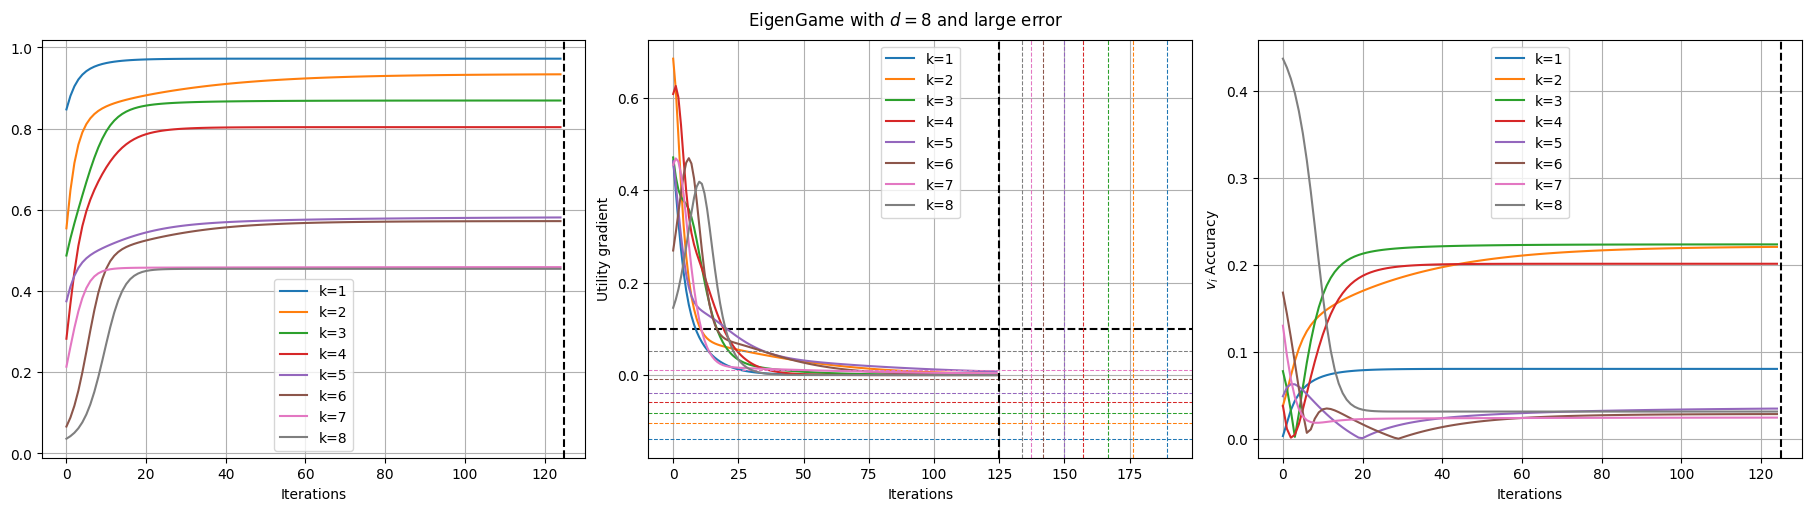

In [ ]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:k]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,5), constrained_layout=True)
fig.suptitle('EigenGame with $d=8$ and large error')

for i, losses in enumerate(losses_list):
  ax1.plot(losses_list[indices[i]], label='k='+str(i+1))
ax1.legend()
ax1.set_xlabel('Iterations')
ax1.set_label('Utility objective')
ax1.axvline(x = opt_iter, color = 'black', label = 'axvline', linestyle='--')
ax1.grid()

ax2.axhline(y = tol, linestyle='--', color='black')
for i, gradients in enumerate(gradients_list):
  ax2.plot(gradients_list[indices[i]], label='k='+str(i+1))
  ax2.axhline(y = tol - opt_grads[indices[i]], linestyle='--', color=colors[i], linewidth=0.75)
  if opt_iters[indices[i]] <= 1000:
    ax2.axvline(x = opt_iters[indices[i]], linestyle='--', color=colors[i], linewidth=0.78)
ax2.legend()
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Utility gradient')
ax2.axvline(x = opt_iter, color = 'black', label = 'axvline', linestyle='--')
ax2.grid()

for i, fid in enumerate(eigenvectors_list_fid):
  ax3.plot(fid, label='k='+str(i+1))
ax3.legend()
ax3.set_xlabel('Iterations')
ax3.set_ylabel('$v_i$ Accuracy')
ax3.axvline(x = opt_iter, color = 'black', label = 'axvline', linestyle='--')
ax3.grid()

fig.savefig("eigengame_large_error.svg")

# Quantum EigenGame using Swaptest

### First attempt

In [ ]:
import networkx as nx
wires = 1

def ansatz(params, wires = 0):
  qml.RandomLayers(params, wires=wires)
  #qml.RX(params[0], wires=wires)
  #qml.RY(params[1], wires=wires)

coeffs = np.array([1, 1])
obs = [qml.PauliX(0), qml.PauliZ(0)]

H_opt = qml.Hamiltonian(-coeffs, obs)
H = qml.Hamiltonian(coeffs, obs)

dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev, interface="autograd")
def cost_function_vqe(params):
    ansatz(params)
    return qml.expval(H_opt)

optimizer = qml.AdagradOptimizer(stepsize=0.1)
steps = 500
params = np.array([[0.5, 0.5, 0.5]], requires_grad=True)

costs = []

for i in range(steps):
    params, cost = optimizer.step_and_cost(cost_function_vqe, params)
    costs.append(-cost)
#eigenvalues.append(cost)

print("Optimal Parameters")
print(params)
print("Cost")
print(-cost)

Optimal Parameters
[[3.92699082e-01 3.92699082e-01 2.02162822e-29]]
Cost
1.4142135623730945


In [ ]:
print(qml.matrix(H))

[[ 1.+0.j  1.+0.j]
 [ 1.+0.j -1.+0.j]]


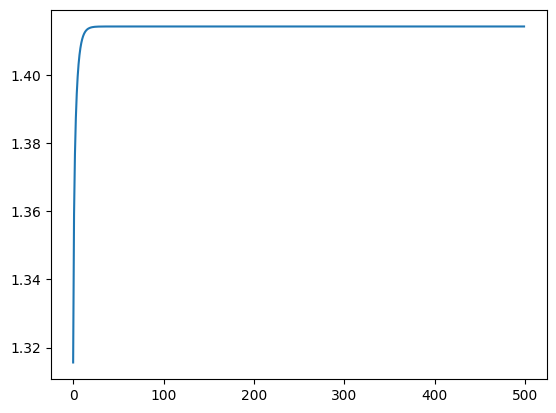

In [ ]:
plt.plot(costs)

In [ ]:
H_matrix = qml.matrix(H)
np.linalg.eigh(H_matrix)

(array([-1.41421356,  1.41421356]),
 array([[ 0.38268343+0.j, -0.92387953+0.j],
        [-0.92387953+0.j, -0.38268343+0.j]]))

### First eigenvalue

In [ ]:
#coeffs = np.array([0.5, 0.25, 0.4, 0.75, 1])
#obs = [qml.PauliX(0) @ qml.PauliZ(1) @ qml.PauliX(2), \
#       qml.Identity(0) @ qml.PauliX(1) @ qml.PauliX(2), \
#       qml.PauliZ(0) @ qml.PauliX(1) @ qml.Identity(2), \
#       qml.PauliZ(0) @ qml.PauliZ(1) @ qml.PauliX(2), \
#       qml.PauliX(0) @ qml.PauliX(1) @ qml.PauliZ(2)]

coeffs = np.array([0.5])
obs = [qml.Identity(0) @ qml.PauliX(1) @ qml.PauliX(2)]

H = qml.Hamiltonian(-coeffs, obs)
H_P = qml.Hamiltonian(coeffs, obs)

H_P_matrix = qml.matrix(H_P)
H_matrix = qml.matrix(H)

In [ ]:
print(H_P_matrix)
print(np.linalg.eig(H_P_matrix))

[[0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j]]
EigResult(eigenvalues=array([ 0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j,
        0.5+0.j, -0.5+0.j]), eigenvectors=tensor([[ 0.70710678+0.j,  0.70710678+0.j, -0.        -0.j,
          0.        +0.j, -0.        -0.j,  0.        +0.j,
         -0.        -0.j,  0.        +0.j],
        [-0.        -0.j,  0.        +0.j,  0.70710678-0.j,
         -0.70710678+0.j, -0.        -0.j,  0.        +0.j,
         -0.        -0.j,  0.        +0.j],
    

In [ ]:
sqrtm(H_P_matrix)

array([[0.35355339+0.35355339j, 0.        +0.j        ,
        0.        +0.j        , 0.35355339-0.35355339j,
        0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.35355339+0.35355339j,
        0.35355339-0.35355339j, 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.35355339-0.35355339j,
        0.35355339+0.35355339j, 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ],
       [0.35355339-0.35355339j, 0.        +0.j        ,
        0.        +0.j        , 0.35355339+0.35355339j,
        0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0

In [ ]:
#d = 2
d = 8
qubits = int(np.ceil(np.log2(d)))
wires = [i for i in range(qubits)]
dev = qml.device("default.qubit", wires=wires)

#coeffs = np.array([1, 1])
#obs = [qml.PauliX(0), qml.PauliZ(0)]

v = []
eigenvalues = []

def ansatz(params, wires = [0, 1, 2]):
#def ansatz(params, wires = [0]):
  qml.RandomLayers(params, wires=wires)
  #qml.BasicEntanglerLayers(params, wires=wires, rotation=qml.RY)

t = 1
depth = 1

#def circuit_vqe(params, wires=[0]):
def circuit_vqe(params, wires=[0, 1, 2]):
    #for w in wires:
    #  qml.Hadamard(wires=w)
    ansatz(params, wires=wires)

@qml.qnode(dev, interface="autograd")
#def cost_function_vqe(params, wires=[0]):
def cost_function_vqe(params, wires=[0, 1, 2]):
    circuit_vqe(params, wires=wires)
    return qml.expval(H)

optimizer = qml.AdagradOptimizer(stepsize=0.1)
steps = 500
#params = np.array([[0.5, 0.5, 0.5]], requires_grad=True)
#params = np.array([[0.5, 0.5, 0.5], [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]], requires_grad=True)
params = np.array([[0.5, 0.5, 0.5, 0.5, 0.5], [0.5, 0.5, 0.5, 0.5, 0.5], [0.5, 0.5, 0.5, 0.5, 0.5]], requires_grad=True)

costs = []
for i in range(steps):
    params, cost = optimizer.step_and_cost(cost_function_vqe, params, wires=wires)
    costs.append(-cost)
eigenvalues.append(cost)

print("Optimal Parameters")
print(params)
print("Cost")
print(-cost)

print(qml.draw(cost_function_vqe)(params))

Optimal Parameters
[[0.45211377 0.57188131 0.46157391 0.53095924 0.42998667]
 [0.53558429 0.46169377 0.46927453 0.4537291  0.36786547]
 [0.46001454 0.46167681 0.5        0.5        0.52747299]]
Cost
0.49999999999999983
0: ─╭RandomLayers(M0)─┤ ╭<𝓗(-0.50)>
1: ─├RandomLayers(M0)─┤ ├<𝓗(-0.50)>
2: ─╰RandomLayers(M0)─┤ ╰<𝓗(-0.50)>

M0 = 
[[0.45211377 0.57188131 0.46157391 0.53095924 0.42998667]
 [0.53558429 0.46169377 0.46927453 0.4537291  0.36786547]
 [0.46001454 0.46167681 0.5        0.5        0.52747299]]


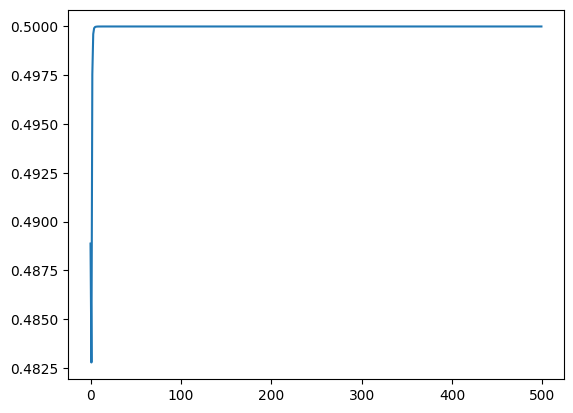

In [ ]:
plt.plot(costs)

In [ ]:
np.linalg.norm(H_matrix)

1.4142135623730951

In [ ]:
print('H_P:', np.linalg.eigh(H_P_matrix))
print('H = -H_P:', np.linalg.eigh(H_matrix))

H_P: EighResult(eigenvalues=array([-0.5, -0.5, -0.5, -0.5,  0.5,  0.5,  0.5,  0.5]), eigenvectors=tensor([[-0.70710678+0.j, -0.        +0.j, -0.        +0.j,
         -0.        +0.j,  0.        +0.j,  0.        +0.j,
          0.        +0.j, -0.70710678+0.j],
        [ 0.        +0.j,  0.70710678+0.j, -0.        +0.j,
         -0.        +0.j,  0.        +0.j, -0.70710678+0.j,
          0.        +0.j,  0.        +0.j],
        [ 0.        +0.j, -0.70710678+0.j, -0.        +0.j,
         -0.        +0.j,  0.        +0.j, -0.70710678+0.j,
          0.        +0.j,  0.        +0.j],
        [ 0.70710678+0.j,  0.        +0.j, -0.        +0.j,
         -0.        +0.j,  0.        +0.j,  0.        +0.j,
          0.        +0.j, -0.70710678+0.j],
        [-0.        +0.j, -0.        +0.j, -0.70710678+0.j,
         -0.        +0.j, -0.70710678+0.j,  0.        +0.j,
          0.        +0.j,  0.        +0.j],
        [-0.        +0.j, -0.        +0.j,  0.        +0.j,
          0.70710678+0

In [ ]:
@qml.qnode(dev, interface="autograd")
def circuit_vqe_state(params):
  circuit_vqe(params)
  return qml.state()

state = circuit_vqe_state(params)
state

tensor([0.26513093-0.37511794j, 0.15685429-0.51418756j,
        0.15685429-0.51418756j, 0.26513093-0.37511794j,
        0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ], requires_grad=True)

In [ ]:
eigvals, eigvecs = eigh(H_P_matrix)
eigvals, eigvecs

(array([-0.5, -0.5, -0.5, -0.5,  0.5,  0.5,  0.5,  0.5]),
 array([[ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
          0.        +0.j, -0.70710678-0.j,  0.        +0.j,
          0.        +0.j,  0.        +0.j],
        [ 0.        +0.j, -0.70710678+0.j,  0.        +0.j,
          0.        +0.j,  0.        +0.j,  0.        +0.j,
         -0.70710678+0.j,  0.        +0.j],
        [ 0.        +0.j,  0.70710678+0.j,  0.        +0.j,
          0.        +0.j,  0.        +0.j,  0.        +0.j,
         -0.70710678+0.j,  0.        +0.j],
        [-0.70710678+0.j,  0.        +0.j,  0.        +0.j,
          0.        +0.j, -0.70710678+0.j,  0.        +0.j,
          0.        +0.j,  0.        +0.j],
        [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j,
          0.        +0.j,  0.        +0.j, -0.70710678-0.j,
          0.        +0.j,  0.        +0.j],
        [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
         -0.70710678+0.j,  0.        +0.j,  0.        +0.j,
  

In [ ]:
np.conjugate(state.flatten()) @ H_P_matrix @ state.flatten()

tensor(0.5+0.j, requires_grad=True)

#### First eigenvector

In [ ]:
v.append(state)
v

[tensor([0.26513093-0.37511794j, 0.15685429-0.51418756j,
         0.15685429-0.51418756j, 0.26513093-0.37511794j,
         0.        +0.j        , 0.        +0.j        ,
         0.        +0.j        , 0.        +0.j        ], requires_grad=True)]

In [ ]:
eigenvalues

[-0.49999999999999983]

### Second eigenvalue

In [ ]:
from pennylane.numpy.tensor import tensor
wires_full = [i for i in range(1+qubits*2)]
dev = qml.device('default.qubit', wires=wires_full)

@qml.qnode(dev, interface="autograd")
def circuit_SWAP(params, v_index = 0):

    # Initial layer of Hadamard
    qml.Hadamard(wires=0)

    # Preparing current circuit
    circuit_vqe(params, wires=wires_full[1:1+qubits])

    # Preparing previous j circuit
    qml.QubitStateVector(v[int(v_index)], wires=wires_full[1+qubits:])
    qml.QubitUnitary(H_matrix, wires=wires_full[1+qubits:])

    # SWAPTest
    for w in wires:
      qml.CSWAP((0, 1+w, 1+qubits+w))
    qml.Hadamard(wires=0)
    return qml.probs(wires=0)

def rewards(params):
    result_rewards = cost_function_vqe(params, wires=wires)
    return result_rewards

def penalty(params, v_index = 0):
    result_penalty = circuit_SWAP(params, v_index = v_index)[0]
    result_penalty = 2*(result_penalty - 0.5)
    result_penalty /= eigenvalues[v_index]
    return result_penalty

def utility(params):
    '''params = reshape_params(params)'''
    result = rewards(params)
    print('Rewards are', result)

    for j in range(len(v)):
      penalty_j = penalty(params, v_index = j)
      print('Penalties',j,'are',penalty_j)

      result -= penalty_j

    return result

optimizer = qml.AdagradOptimizer(stepsize=0.1)
steps = 500
#params = np.array([[-0.5, -0.5, -0.5], [-0.5, -0.5, -0.5], [-0.5, -0.5, -0.5]], requires_grad=True)
params = np.array([[-0.5, -0.5, -0.5, -0.5, -0.5], [-0.5, -0.5, -0.5, -0.5, -0.5], [-0.5, -0.5, -0.5, -0.5, -0.5]], requires_grad=True)
costs = []

'''# Define a helper function to reshape the flat parameters back to the nested structure
def reshape_params(flat_params):

    return flat_params.reshape(params.shape)

    #split_index = params[0].size  # Index at which to split the flat parameters
    #new_pars_classical = flat_params[:split_index].reshape(params[0].shape)
    #new_pars_quantum = flat_params[split_index:].reshape(params[1].shape)
    #return [new_pars_classical, new_pars_quantum]'''

for i in range(steps):
    print('iter',i)
    print('params', params)

    '''# Flatten the parameters before passing them to the optimizer
    flat_params = params.flatten()

    #print('flat', flat_params)
    #print('reshaped', reshape_params(flat_params))

    flat_params = optimizer.step(utility, flat_params)

    print('new params', flat_params)

    params = reshape_params(flat_params)

    cost = utility(params)'''

    grad, cost = optimizer.compute_grad(utility, (params,), {})
    grad = grad[0]

    #v_i = circuit_vqe_state(params)

    #print('grad',grad)
    #print('v_i',params)
    #print('grad @ v_i',grad @ params.T)
    grad_R = grad - ((grad @ params.T) @ params)
    params = optimizer.apply_grad(grad_R, (params,))[0]

    #params, cost = optimizer.step_and_cost(utility, params)

    print('cost',-cost)
    costs.append(-cost_function_vqe(params, wires=wires))

eigenvalues.append(cost_function_vqe(params, wires=wires))

print("Optimal Parameters")
print(params)
print("Cost")
print(-cost)

print(qml.draw(circuit_SWAP)(params))

iter 0
params [[-0.5 -0.5 -0.5 -0.5 -0.5]
 [-0.5 -0.5 -0.5 -0.5 -0.5]
 [-0.5 -0.5 -0.5 -0.5 -0.5]]
Rewards are Autograd ArrayBox with value 0.0952256498854904
Penalties 0 are Autograd ArrayBox with value 1.3163257117036251
cost 1.2211000618181347
iter 1
params [[-0.40000007 -0.4        -0.40000002 -0.40000001 -0.40000004]
 [-0.40000007 -0.4        -0.40000002 -0.40000001 -0.40000004]
 [-0.40000007 -0.4        -0.40000002 -0.40000001 -0.40000004]]
Rewards are Autograd ArrayBox with value 0.19555444862488328
Penalties 0 are Autograd ArrayBox with value 1.3962570316008822
cost 1.200702582975999
iter 2
params [[-0.3283269  -0.34579831 -0.3908838  -0.3567766  -0.46837083]
 [-0.3283269  -0.34579831 -0.3908838  -0.3567766  -0.46837083]
 [-0.3283269  -0.34579831 -0.3908838  -0.3567766  -0.46837083]]
Rewards are Autograd ArrayBox with value 0.14164439881912116
Penalties 0 are Autograd ArrayBox with value 1.4059522468464007
cost 1.2643078480272796
iter 3
params [[-0.26043942 -0.2995372  -0.38584

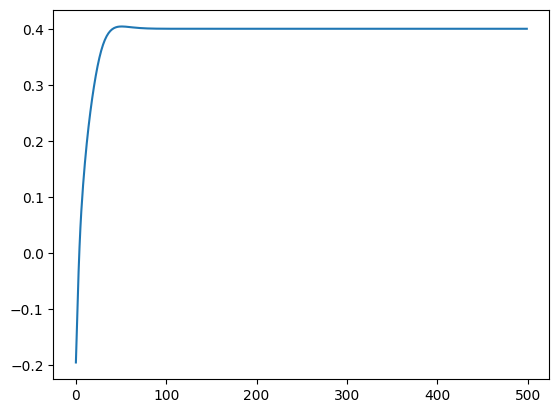

In [ ]:
plt.plot(costs)

#### Second eigenvector

In [ ]:
state = circuit_vqe_state(params)
v.append(state)
v

[tensor([0.26513093-0.37511794j, 0.15685429-0.51418756j,
         0.15685429-0.51418756j, 0.26513093-0.37511794j,
         0.        +0.j        , 0.        +0.j        ,
         0.        +0.j        , 0.        +0.j        ], requires_grad=True),
 tensor([0.82995827+0.0602965j , 0.03391461+0.06565453j,
         0.28666936+0.00247319j, 0.4661876 +0.05056259j,
         0.        +0.j        , 0.        +0.j        ,
         0.        +0.j        , 0.        +0.j        ], requires_grad=True)]

In [ ]:
np.conjugate(state.flatten()) @ H_P_matrix @ state.flatten()

tensor(0.39984966+0.j, requires_grad=True)

In [ ]:
eigenvalues

[-0.49999999999999983, tensor(-0.39984966, requires_grad=True)]

### Third eigenvalue

In [ ]:
from pennylane.numpy.tensor import tensor
#wires_full = [i for i in range(3*qubits)]
#dev = qml.device('default.qubit', wires=wires_full)

#mask = np.zeros(2**(3*qubits))
#mask[:2**(3*qubits)//2] = 1

optimizer = qml.AdamOptimizer()
steps = 500
params = np.array([[-0.5, -0.5, -0.5, 0.5, 0.5], [-0.5, -0.5, -0.5, 0.5, 0.5], [-0.5, -0.5, -0.5, 0.5, 0.5]], requires_grad=True)
costs = []

'''# Define a helper function to reshape the flat parameters back to the nested structure
def reshape_params(flat_params):

    return flat_params.reshape(params.shape)

    #split_index = params[0].size  # Index at which to split the flat parameters
    #new_pars_classical = flat_params[:split_index].reshape(params[0].shape)
    #new_pars_quantum = flat_params[split_index:].reshape(params[1].shape)
    #return [new_pars_classical, new_pars_quantum]'''

for i in range(steps):
    print('iter',i)
    print('old params', params)

    '''# Flatten the parameters before passing them to the optimizer
    flat_params = params.flatten()

    #print('flat', flat_params)
    #print('reshaped', reshape_params(flat_params))

    flat_params = optimizer.step(utility, flat_params)

    print('new params', flat_params)

    params = reshape_params(flat_params)

    cost = utility(params)'''

    params, cost = optimizer.step_and_cost(utility, params)
    print('new params', params)

    print('cost',-cost)
    costs.append(-cost_function_vqe(params, wires=wires))

    #if i>200:
    #  input()

eigenvalues.append(cost_function_vqe(params, wires=wires))

print("Optimal Parameters")
print(params)
print("Cost")
print(-cost)

print(qml.draw(circuit_SWAP)(params))

Se han truncado las últimas 5000 líneas del flujo de salida.
Penalties 0 are Autograd ArrayBox with value 1.469597052919827
Penalties 1 are Autograd ArrayBox with value 1.795309270286371
new params [[-0.8758694  -0.9676444  -0.21398914 -0.01771372  0.95418361]
 [-0.94497951 -1.01448383 -0.67705308  0.96643415  0.16153897]
 [-0.97822499 -1.03742828 -0.5        -0.0673259   0.74098084]]
cost 3.593670560350037
iter 49
old params [[-0.8758694  -0.9676444  -0.21398914 -0.01771372  0.95418361]
 [-0.94497951 -1.01448383 -0.67705308  0.96643415  0.16153897]
 [-0.97822499 -1.03742828 -0.5        -0.0673259   0.74098084]]
Rewards are Autograd ArrayBox with value -0.3383668208758213
Penalties 0 are Autograd ArrayBox with value 1.4681869036424484
Penalties 1 are Autograd ArrayBox with value 1.7952012439513694
new params [[-0.87230916 -0.97333324 -0.21933208 -0.03012419  0.95969387]
 [-0.94872788 -1.02404868 -0.68977463  0.97310582  0.16114477]
 [-0.9844571  -1.04762    -0.5        -0.08088996  0.7

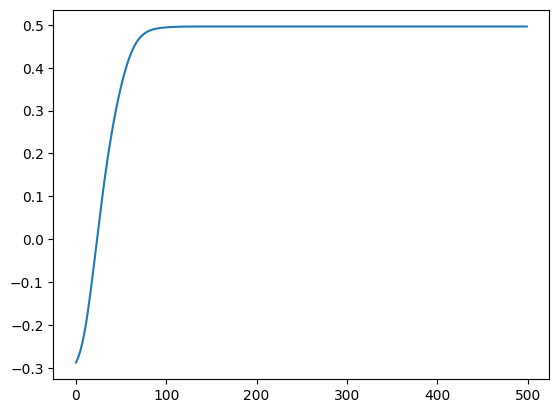

In [ ]:
plt.plot(costs)

#### Third eigenvector

In [ ]:
state = circuit_vqe_state(params)
v.append(state)
v

[tensor([0.26513093-0.37511794j, 0.15685429-0.51418756j,
         0.15685429-0.51418756j, 0.26513093-0.37511794j,
         0.        +0.j        , 0.        +0.j        ,
         0.        +0.j        , 0.        +0.j        ], requires_grad=True),
 tensor([0.82995827+0.0602965j , 0.03391461+0.06565453j,
         0.28666936+0.00247319j, 0.4661876 +0.05056259j,
         0.        +0.j        , 0.        +0.j        ,
         0.        +0.j        , 0.        +0.j        ], requires_grad=True),
 tensor([-0.28421072-0.27853409j,  0.52181812+0.35175362j,
          0.48224397+0.32268321j, -0.24185997-0.22458475j,
          0.        +0.j        ,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ], requires_grad=True)]

In [ ]:
np.conjugate(state.flatten()) @ H_P_matrix @ state.flatten()

tensor(0.49644234+0.j, requires_grad=True)

In [ ]:
eigenvalues

[-0.49999999999999983,
 tensor(-0.39984966, requires_grad=True),
 tensor(-0.49644234, requires_grad=True)]

### Fourth eigenvalue

In [ ]:
optimizer = qml.AdagradOptimizer(stepsize=0.01)
steps = 500
params = np.array([[-0.5, -0.5, -0.5], [-0.5, -0.5, -0.5], [-0.5, -0.5, -0.5]], requires_grad=True)
costs = []

for i in range(steps):
    print('iter',i)
    params_prev = params
    params, cost = optimizer.step_and_cost(cost_function_SWAP, params)
    params1, cost1 = optimizer.step_and_cost(cost_function_SWAP, params)
    params2, cost2 = optimizer.step_and_cost(cost_function_vqe, params)
    params3, cost3 = optimizer.step_and_cost(penalty, params, v_index=0)
    grad2 = params2-params_prev
    grad3 = params3-params_prev

    params += grad2 + grad3

    print('cost',-cost)
    costs.append(-cost_function_vqe(params, wires=wires))
#eigenvalues.append(-cost)

print("Optimal Parameters")
print(params)
print("Cost")
print(-cost)

print(qml.draw(circuit_SWAP)(params))

iter 0


NameError: name 'cost_function_SWAP' is not defined

In [ ]:
plt.plot(costs)

#### Fourth eigenvector

In [ ]:
state = circuit_vqe_state(params)
v.append(state)
v

In [ ]:
eigenvalues.append(np.conjugate(state.flatten()) @ H_P_matrix @ state.flatten())

In [ ]:
eigenvalues

## QAOA (does not apply)

### Third eigenvalue

In [ ]:
cost_h_SWAP = qml.Hamiltonian(
    [1/2, -1/2],
    [qml.Identity(wires), qml.PauliZ(wires) @ qml.PauliZ(1+wires)]
)
print('Cost Hamiltonian:',cost_h_SWAP)

mixer_h_SWAP = qaoa.x_mixer(range(wires, 2*wires))
print('Mixer Hamiltonian:',mixer_h_SWAP)

#H = qml.Hamiltonian(
#    [1, 1, 0.5],
#    [qml.PauliX(0), qml.PauliZ(1), qml.PauliZ(0) @ qml.PauliY(1)]
#)
H_SWAP = cost_h_SWAP
print('Hamiltonian:', H_SWAP)

Cost Hamiltonian:   (0.5) [I2]
+ (-0.5) [Z2 Z3]
Mixer Hamiltonian:   (1) [X2]
+ (1) [X3]
Hamiltonian:   (0.5) [I2]
+ (-0.5) [Z2 Z3]


In [ ]:
from pennylane.numpy.tensor import tensor
dev = qml.device('lightning.qubit', wires=3*wires)

def qaoa_layer_SWAP(gamma, alpha):
    qaoa.cost_layer(gamma, cost_h_SWAP)
    qaoa.mixer_layer(alpha, mixer_h_SWAP)

@qml.qnode(dev)
def circuit_SWAP(params, **kwargs):
    for w in range(2*wires):
        qml.Hadamard(wires=w)
    qml.layer(qaoa_layer_SWAP, depth, params[0], params[1])
    #print('v',v)
    print('params',params)
    v_index = params[2][0]
    if type(v_index) == tensor:
      v_index = params[2][0]
    else:
      v_index = params[2][0]._value
    qml.QubitStateVector(v[int(v_index)], wires=range(2*wires, 3*wires))
    for w in range(wires):
      qml.CSWAP((w, w + wires, w + 2*wires))
    for w in range(wires):
        qml.Hadamard(wires=w)
    return qml.probs(wires=range(3*wires))
    #print(qml.state())

print(qml.draw(circuit_SWAP)(np.array([[0.5], [0.5], [0]], requires_grad=True)))

def cost_function_SWAP(params):
    #circuit_qaoa(params)
    #result_qaoa = qml.expval(H_qaoa)
    result_qaoa = cost_function_qaoa(params)
    result = result_qaoa
    #print(result_qaoa)
    for j in range(len(v)):
      result_SWAP = circuit_SWAP(params)
      result_SWAP = 2*(result_SWAP[:len(result_SWAP)//2].sum() - 0.5)
      result -= (result_SWAP/eigenvalues[j])
    #print(result_SWAP)
    print(result)
    return result

def ffd_update(params, eta=0.01 , h=0.005):
    i = np.random.randint(params.size)
    shape = params.shape
    dt = np.eye(1,params.size,i)
    # we reshape theta to match the shape of dt
    theta = theta.reshape(-1)
    dtheta = (cost_function_SWAP((theta+dt*h).reshape(shape))
                - cost_function_SWAP((theta-dt*h).reshape(shape)))/(2*h)
    # we reshape back to the original shape of theta
    return (theta - eta*dtheta*dt).reshape(shape)

optimizer = qml.GradientDescentOptimizer()
steps = 500
params = np.array([[2.5], [2.5], [0]], requires_grad=True)

for i in range(steps):
    params, cost = optimizer.step_and_cost(cost_function_SWAP, params)
eigenvalues.append(cost)

print("Optimal Parameters")
print(params)
print("Cost")
print(cost)

params [[0.5]
 [0.5]
 [0. ]]
0: ──H──────────────────────────────────────────────────────────────────────────────╭●─────H───────┤
1: ──H──────────────────────────────────────────────────────────────────────────────│─────╭●─────H─┤
2: ──H───╭ApproxTimeEvolution(0.50,-0.50,0.50)─╭ApproxTimeEvolution(1.00,1.00,0.50)─├SWAP─│────────┤
3: ──H───╰ApproxTimeEvolution(0.50,-0.50,0.50)─╰ApproxTimeEvolution(1.00,1.00,0.50)─│─────├SWAP────┤
4: ─╭|Ψ⟩────────────────────────────────────────────────────────────────────────────╰SWAP─│────────┤
5: ─╰|Ψ⟩──────────────────────────────────────────────────────────────────────────────────╰SWAP────┤

  ╭Probs
  ├Probs
  ├Probs
  ├Probs
  ├Probs
  ╰Probs
params Autograd ArrayBox with value [[2.5]
 [2.5]
 [0. ]]
params Autograd ArrayBox with value [[2.5]
 [2.5]
 [0. ]]
Autograd ArrayBox with value 0.9416940764709799
params Autograd ArrayBox with value [[2.497066  ]
 [2.51004322]
 [0.        ]]
params Autograd ArrayBox with value [[2.497066  ]
 [2.51004322]
 [0

#### Third eigenvector

In [ ]:
v.append(circuit_qaoa_state(params))
v

[array([-0.0209907-0.0209907j,  0.4995592+0.4995592j,
         0.4995592+0.4995592j, -0.0209907-0.0209907j]),
 array([-0.00203897-0.00203897j,  0.49999584+0.49999584j,
         0.49999584+0.49999584j, -0.00203897-0.00203897j]),
 array([0.03601901+0.03601901j, 0.49870094+0.49870094j,
        0.49870094+0.49870094j, 0.03601901+0.03601901j])]

In [ ]:
eigenvalues

[array(-0.99821984), -0.49872759162849334, 0.490536774724641]

### Fourth eigenvalue

In [ ]:
cost_h_SWAP = qml.Hamiltonian(
    [1/2, -1/2],
    [qml.Identity(wires), qml.PauliZ(wires) @ qml.PauliZ(1+wires)]
)
print('Cost Hamiltonian:',cost_h_SWAP)

mixer_h_SWAP = qaoa.x_mixer(range(wires, 2*wires))
print('Mixer Hamiltonian:',mixer_h_SWAP)

#H = qml.Hamiltonian(
#    [1, 1, 0.5],
#    [qml.PauliX(0), qml.PauliZ(1), qml.PauliZ(0) @ qml.PauliY(1)]
#)
H_SWAP = cost_h_SWAP
print('Hamiltonian:', H_SWAP)

Cost Hamiltonian:   (0.5) [I2]
+ (-0.5) [Z2 Z3]
Mixer Hamiltonian:   (1) [X2]
+ (1) [X3]
Hamiltonian:   (0.5) [I2]
+ (-0.5) [Z2 Z3]


In [ ]:
from pennylane.numpy.tensor import tensor
dev = qml.device('lightning.qubit', wires=3*wires)

def qaoa_layer_SWAP(gamma, alpha):
    qaoa.cost_layer(gamma, cost_h_SWAP)
    qaoa.mixer_layer(alpha, mixer_h_SWAP)

@qml.qnode(dev)
def circuit_SWAP(params, **kwargs):
    for w in range(2*wires):
        qml.Hadamard(wires=w)
    qml.layer(qaoa_layer_SWAP, depth, params[0], params[1])
    #print('v',v)
    print('params',params)
    v_index = params[2][0]
    if type(v_index) == tensor:
      v_index = params[2][0]
    else:
      v_index = params[2][0]._value
    qml.QubitStateVector(v[int(v_index)], wires=range(2*wires, 3*wires))
    for w in range(wires):
      qml.CSWAP((w, w + wires, w + 2*wires))
    for w in range(wires):
        qml.Hadamard(wires=w)
    return qml.probs(wires=range(3*wires))
    #print(qml.state())

print(qml.draw(circuit_SWAP)(np.array([[0.5], [0.5], [0]], requires_grad=True)))

def cost_function_SWAP(params):
    #circuit_qaoa(params)
    #result_qaoa = qml.expval(H_qaoa)
    result_qaoa = cost_function_qaoa(params)
    result = result_qaoa
    #print(result_qaoa)
    for j in range(len(v)):
      result_SWAP = circuit_SWAP(params)
      result_SWAP = 2*(result_SWAP[:len(result_SWAP)//2].sum() - 0.5)
      result -= (result_SWAP/eigenvalues[j])
    #print(result_SWAP)
    print(result)
    return result

def ffd_update(params, eta=0.01 , h=0.005):
    i = np.random.randint(params.size)
    shape = params.shape
    dt = np.eye(1,params.size,i)
    # we reshape theta to match the shape of dt
    theta = theta.reshape(-1)
    dtheta = (cost_function_SWAP((theta+dt*h).reshape(shape))
                - cost_function_SWAP((theta-dt*h).reshape(shape)))/(2*h)
    # we reshape back to the original shape of theta
    return (theta - eta*dtheta*dt).reshape(shape)

optimizer = qml.GradientDescentOptimizer()
steps = 500
params = np.array([[2.5], [2.5], [0]], requires_grad=True)

for i in range(steps):
    params, cost = optimizer.step_and_cost(cost_function_SWAP, params)
eigenvalues.append(cost)

print("Optimal Parameters")
print(params)
print("Cost")
print(cost)

ValueError: ignored

#### Fourth eigenvector

In [ ]:
v.append(circuit_qaoa_state(params))
v

[array([-0.0209907-0.0209907j,  0.4995592+0.4995592j,
         0.4995592+0.4995592j, -0.0209907-0.0209907j]),
 array([-0.00203897-0.00203897j,  0.49999584+0.49999584j,
         0.49999584+0.49999584j, -0.00203897-0.00203897j]),
 array([0.03601901+0.03601901j, 0.49870094+0.49870094j,
        0.49870094+0.49870094j, 0.03601901+0.03601901j]),
 array([-0.00267526-0.00267526j,  0.49999284+0.49999284j,
         0.49999284+0.49999284j, -0.00267526-0.00267526j])]

In [ ]:
eigenvalues

[array(-0.99821984),
 -0.49872759162849334,
 0.490536774724641,
 -0.5153640640235926]

### Deflation test

In [ ]:
eigenvalues

[array(-0.99821984), -0.4973281668222913]

In [ ]:
H_matrix

array([[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j]])

In [ ]:
H_1 = H_matrix - eigenvalues[0] * np.outer(np.conjugate(v[0]), v[0])/np.dot(np.conjugate(v[0]), v[0])
H_1.real

tensor([[ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        , -0.00178016,  0.        ,  0.        ],
        [ 0.        ,  0.        , -1.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ]], requires_grad=True)

In [ ]:
H_2 = H_1 - eigenvalues[1] * np.outer(np.conjugate(v[1]), v[1])/np.dot(np.conjugate(v[1]), v[1])
H_2.real

tensor([[ 0.0008838 , -0.02195175, -0.02195175,  0.0008838 ],
        [-0.02195175, -0.25241008,  0.74758992, -0.02195175],
        [-0.02195175,  0.74758992, -0.25241008, -0.02195175],
        [ 0.0008838 , -0.02195175, -0.02195175,  0.0008838 ]], requires_grad=True)

In [ ]:
H_3 = H_2 - eigenvalues[2] * np.outer(np.conjugate(v[2]), v[2])/np.dot(np.conjugate(v[2]), v[2])
H_3.real

tensor([[-3.89017019e-04, -3.95744875e-02, -3.95744875e-02,
         -3.89017019e-04],
        [-3.95744875e-02, -4.96405656e-01,  5.03594344e-01,
         -3.95744875e-02],
        [-3.95744875e-02,  5.03594344e-01, -4.96405656e-01,
         -3.95744875e-02],
        [-3.89017019e-04, -3.95744875e-02, -3.95744875e-02,
         -3.89017019e-04]], requires_grad=True)

In [ ]:
H_4 = H_3 - eigenvalues[3] * np.outer(np.conjugate(v[3]), v[3])/np.dot(np.conjugate(v[3]), v[3])
H_4.real

tensor([[-3.81640071e-04, -4.09532016e-02, -4.09532016e-02,
         -3.81640071e-04],
        [-4.09532016e-02, -2.38731001e-01,  7.61268999e-01,
         -4.09532016e-02],
        [-4.09532016e-02,  7.61268999e-01, -2.38731001e-01,
         -4.09532016e-02],
        [-3.81640071e-04, -4.09532016e-02, -4.09532016e-02,
         -3.81640071e-04]], requires_grad=True)

### Second eigenvalue - try 2

In [ ]:
class FFDOptimizer:
    def __init__(self, eta=0.01 , h=0.005):
        self.h = h
        self.eta = eta

    def step(self, objective_fn, params):
        i = np.random.randint(params.size)
        shape = params.shape
        dt = np.eye(1,params.size,i)
        params = params.reshape(-1)
        dparams = (cost_function_SWAP((params+dt*self.h).reshape(shape))
                    -cost_function_SWAP((params-dt*self.h).reshape(shape)))/(2*self.h)
        return (params - self.eta*params*dt).reshape(shape)

    def step_and_cost(self, objective_fn, params):
        params = self.step(objective_fn, params)
        return params, objective_fn(params)

## Sequential quantum EigenGame

In [ ]:
def init_weights(n_layers, n_rotations):
  shape = qml.RandomLayers.shape(n_layers = n_layers, n_rotations = n_rotations)
  return np.array(np.random.random(shape), requires_grad=True)

def ansatz(params, wires = [0]):
  qml.RandomLayers(params, wires=wires)

def circuit_vqe(params, wires=[0]):
    for w in wires:
      qml.Hadamard(wires=w)
    ansatz(params, wires=wires)

In [ ]:
def quantum_eigengame(H, k=1):

  d = qml.matrix(H).shape[0]
  qubits = int(np.log2(d))
  wires = [i for i in range(qubits)]
  dev0 = qml.device("default.qubit", wires=wires)

  @qml.qnode(dev0, interface="autograd")
  def cost_function_vqe_0(params, wires=[0]):
      circuit_vqe(params, wires=wires)
      #return qml.expval(H_opt)
      return qml.expval(H)

  @qml.qnode(dev0, interface="autograd")
  def circuit_vqe_state_0(params):
    circuit_vqe(params)
    return qml.state()

  wires_full = [i for i in range(3*qubits)]
  dev = qml.device("default.qubit", wires=wires_full)
  @qml.qnode(dev, interface="autograd")
  def circuit_vqe_state(params):
    circuit_vqe(params)
    return qml.state()

  @qml.qnode(dev, interface="autograd")
  def cost_function_vqe(params, wires=[0]):
      circuit_vqe(params, wires=wires)
      #return qml.expval(H_opt)
      return qml.expval(H)

  H_matrix = qml.matrix(H)
  @qml.qnode(dev, interface="autograd")
  def circuit_SWAP(params, v_index = 0):

      # Initial layer of Hadamard
      for w in wires:
        qml.Hadamard(wires=w)

      # Preparing current circuit
      circuit_vqe(params, wires=wires_full[qubits:2*qubits])

      # Preparing previous j circuit
      qml.QubitStateVector(v[int(v_index)], wires=wires_full[2*qubits:])
      qml.QubitUnitary(H_matrix, wires=wires_full[2*qubits:])

      # SWAPTest
      for w in wires:
        qml.CSWAP((w, w + qubits, w + 2*qubits))
      for w in wires:
          qml.Hadamard(wires=w)
      return qml.probs(wires=wires_full)

  def cost_function_SWAP(params):

    # Rewards
    result_vqe = cost_function_vqe(params, wires=wires)
    result = result_vqe
    print('Rewards are', result)

    # Penalties
    for j in range(len(v)):
      result_SWAP = circuit_SWAP(params, v_index = j)
      result_SWAP = (2*np.abs(result_SWAP.flatten()[:len(result_SWAP.flatten())//2].sum() - 0.5))

      print('Penalties',j,'are',result_SWAP)
      result += result_SWAP/eigs[j]

    print('Total result is',result)
    return result

  def penalty(params, v_index=0):
    result_SWAP = circuit_SWAP(params, v_index = 0)
    result_SWAP = (2*np.abs(result_SWAP.flatten()[:len(result_SWAP.flatten())//2].sum() - 0.5))
    result_SWAP /= eigs[0]
    return result_SWAP

  optimizer = qml.AdagradOptimizer(stepsize=0.1)
  steps = 500
  #params = np.array([[0.5, 0.5, 0.5], [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]], requires_grad=True)
  params = init_weights(4, 8)

  v = []
  eigs = []
  costs_list = []

  for i in range(k):
    if i == 0:
      costs = []
      for i in range(steps):
          params, cost = optimizer.step_and_cost(cost_function_vqe_0, params, wires=wires)
          costs.append(cost)
      eigs.append(cost_function_vqe_0(params, wires=wires))
    else:
      costs = []
      for i in range(steps):
        params_prev = params
        params, cost = optimizer.step_and_cost(cost_function_SWAP, params)
        params1, cost1 = optimizer.step_and_cost(cost_function_vqe, params)
        params2, cost2 = optimizer.step_and_cost(penalty, params, v_index=0)
        grad1 = params1-params_prev
        grad2 = params2-params_prev

        params -= grad1 + grad2
        costs.append(cost_function_vqe(params, wires=wires))
      eigs.append(cost_function_vqe(params, wires=wires))

    state = circuit_vqe_state_0(params)
    v.append(state)
    #eigs.append(np.real(np.conjugate(state.flatten()) @ H_matrix @ state.flatten()))
    costs_list.append(costs)

  return eigs, v, costs_list

In [ ]:
#coeffs = np.array([1, 1])
#obs = [qml.PauliX(0), qml.PauliZ(0)]

coeffs = np.array([1, -1, 1])
obs = [qml.PauliX(0) @ qml.PauliZ(1) @ qml.Identity(2), \
       qml.Identity(0) @ qml.PauliX(1) @ qml.PauliX(2), \
       qml.Identity(0) @ qml.PauliX(1) @ qml.Identity(2)]

#H_opt = qml.Hamiltonian(-coeffs, obs)
#H = qml.Hamiltonian(coeffs, obs)

H_P = qml.Hamiltonian(coeffs, obs)
H = qml.Hamiltonian(-coeffs, obs)

#eigenvals, eigenvecs, costs_list = quantum_eigengame(H_opt, k=5)
eigenvals, eigenvecs, costs_list = quantum_eigengame(H, k=3)

Se han truncado las últimas 5000 líneas del flujo de salida.
Rewards are Autograd ArrayBox with value 2.2205012162640774
Penalties 0 are Autograd ArrayBox with value 3.625551083819955
Penalties 1 are Autograd ArrayBox with value 4.036387495533691
Penalties 2 are Autograd ArrayBox with value 4.031811351360244
Total result is Autograd ArrayBox with value 4.21493037453353
Rewards are Autograd ArrayBox with value 2.220729883712199
Penalties 0 are Autograd ArrayBox with value 3.6320253126274835
Penalties 1 are Autograd ArrayBox with value 4.044196332898873
Penalties 2 are Autograd ArrayBox with value 4.0396283550551
Total result is Autograd ArrayBox with value 4.219266512406266
Rewards are Autograd ArrayBox with value 2.2209564358316416
Penalties 0 are Autograd ArrayBox with value 3.6384258872424553
Penalties 1 are Autograd ArrayBox with value 4.051906001560283
Penalties 2 are Autograd ArrayBox with value 4.047346287025507
Total result is Autograd ArrayBox with value 4.223544631151273
Rewar

In [ ]:
eigenvals

[tensor(-2.23606794, requires_grad=True),
 tensor(2.22949706, requires_grad=True),
 tensor(2.2332236, requires_grad=True),
 tensor(2.23332971, requires_grad=True),
 tensor(2.23423075, requires_grad=True)]

In [ ]:
qml.eigvals(H_P)

/usr/local/lib/python3.10/dist-packages/pennylane/ops/functions/eigvals.py:120: UserWarning: For Hamiltonians, the eigenvalues will be computed numerically. This may be computationally intensive for a large number of wires. Consider using a sparse representation of the Hamiltonian with qml.SparseHamiltonian.
  warnings.warn(


array([-2.23606798, -2.23606798, -1.        , -1.        ,  1.        ,
        1.        ,  2.23606798,  2.23606798])

In [ ]:
from pennylane import qchem

#symbols, coordinates = qchem.read_structure('h2o.xyz')

#symbols = ["H", "O", "H"]
#coordinates = np.array([-0.0399, -0.0038, 0.0, 1.5780, 0.8540, 0.0, 2.7909, -0.5159, 0.0])

symbols, coordinates = (['H', 'H'], np.array([0., 0., -0.66140414, 0., 0., 0.66140414]))

H_P, qubits = qchem.molecular_hamiltonian(symbols, coordinates)
print("Number of qubits: {:}".format(qubits))
print("Qubit Hamiltonian")
print(H_P)
coeffs = H_P.coeffs
ops = H_P.ops
H = qml.Hamiltonian(-coeffs, ops)
eigenvals, eigenvecs, costs_list = quantum_eigengame(H, k=3)
print(eigenvals)

Number of qubits: 4
Qubit Hamiltonian
  (-0.24274280239795765) [Z3]
+ (-0.2427428023979576) [Z2]
+ (-0.04207897977473346) [I0]
+ (0.17771287564453386) [Z1]
+ (0.17771287564453392) [Z0]
+ (0.12293305067503807) [Z0 Z2]
+ (0.12293305067503807) [Z1 Z3]
+ (0.16768319448852503) [Z0 Z3]
+ (0.16768319448852503) [Z1 Z2]
+ (0.1705973838334139) [Z0 Z1]
+ (0.1762764074046272) [Z2 Z3]
+ (-0.044750143813486964) [Y0 Y1 X2 X3]
+ (-0.044750143813486964) [X0 X1 Y2 Y3]
+ (0.044750143813486964) [Y0 X1 X2 Y3]
+ (0.044750143813486964) [X0 Y1 Y2 X3]
Rewards are Autograd ArrayBox with value -1.016087155297215
Penalties 0 are Autograd ArrayBox with value 0.4288599134016128
Total result is Autograd ArrayBox with value -1.4381571629395882
Rewards are Autograd ArrayBox with value -1.015968813200908
Penalties 0 are Autograd ArrayBox with value 0.4298694109712462
Total result is Autograd ArrayBox with value -1.4390323355869432
Rewards are Autograd ArrayBox with value -1.0158254640853097
Penalties 0 are Autograd Arr

In [ ]:
eigenvals

[tensor(-1.01608716, requires_grad=True),
 tensor(-1.01534472, requires_grad=True),
 tensor(-1.01516024, requires_grad=True)]

In [ ]:
eigenvecs

[tensor([ 0.30850838+0.94438642j,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ,
         -0.07423625-0.08628937j,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ], requires_grad=True),
 tensor([ 0.3119997 +0.94661379j,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ,
         -0.06015882-0.05440072j,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ,
          0.        +0.j        ,  0.        +0.j        ], requires_grad=True),
 tensor([ 0.

In [ ]:
H_P_matrix = qml.matrix(H_P)
eigs, _ = np.linalg.eigh(H_P_matrix)
eigs

array([-1.13618945, -0.52188556, -0.52188556, -0.47845306, -0.47845306,
       -0.47845306, -0.40318375, -0.40318375, -0.12045191,  0.30766775,
        0.30766775,  0.44908565,  0.44908565,  0.5833141 ,  0.75596745,
        1.01608716])

In [ ]:
H_matrix = qml.matrix(H)
eigs, _ = np.linalg.eigh(H_matrix)
eigs

array([-1.01608716, -0.75596745, -0.5833141 , -0.44908565, -0.44908565,
       -0.30766775, -0.30766775,  0.12045191,  0.40318375,  0.40318375,
        0.47845306,  0.47845306,  0.47845306,  0.52188556,  0.52188556,
        1.13618945])

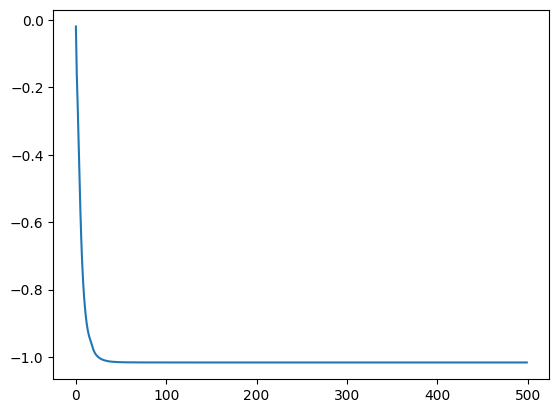

In [ ]:
plt.plot(costs_list[0])

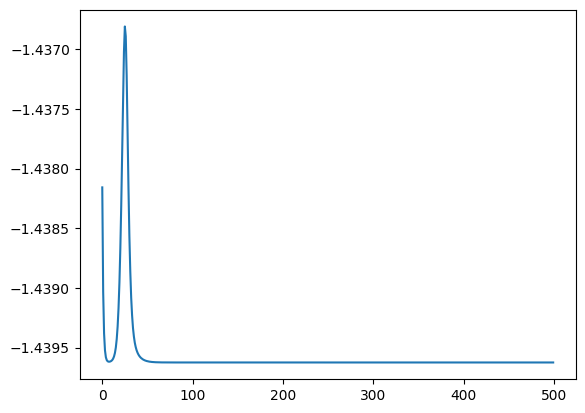

In [ ]:
plt.plot(costs_list[1])

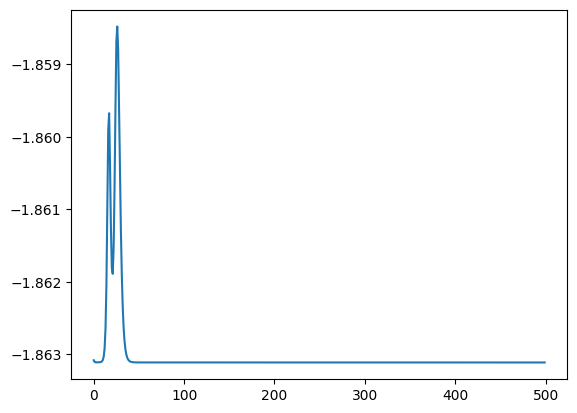

In [ ]:
plt.plot(costs_list[2])

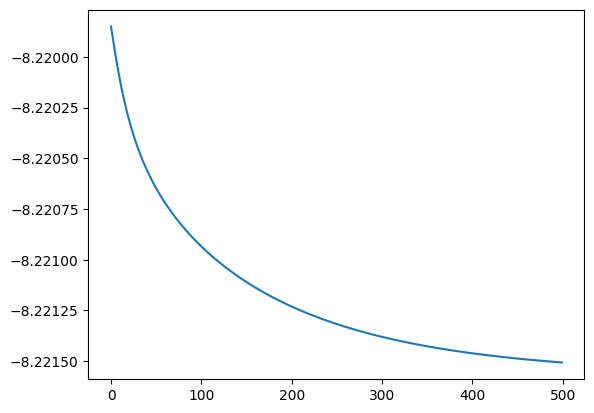

In [ ]:
plt.plot(costs_list[3])

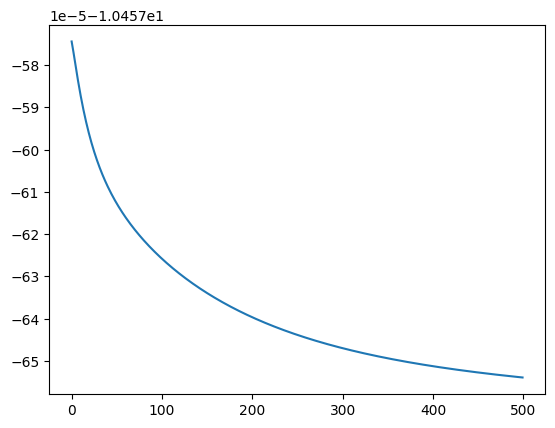

In [ ]:
plt.plot(costs_list[4])

In [ ]:
from pennylane.numpy.tensor import tensor
wires_full = [i for i in range(3*qubits)]
dev = qml.device('default.qubit', wires=wires_full)

mask = np.zeros(2**(3*qubits))
mask[:2**(3*qubits)//2] = 1

#def ansatz(params, wires = 0):
#  qml.RandomLayers(params, wires=wires)

@qml.qnode(dev, interface="autograd")
def circuit_SWAP(params, v_index = 0):

    # Initial layer of Hadamard
    for w in wires:
      qml.Hadamard(wires=w)

    # Preparing current circuit
    circuit_vqe(params, wires=wires_full[qubits:2*qubits])
    #qml.QubitUnitary(X, wires=wires_full[qubits:2*qubits])

    # Preparing previous j circuit
    qml.QubitStateVector(v[int(v_index)], wires=wires_full[2*qubits:])
    qml.QubitUnitary(H_matrix, wires=wires_full[2*qubits:])

    # SWAPTest
    for w in wires:
      qml.CSWAP((w, w + qubits, w + 2*qubits))
    for w in wires:
        qml.Hadamard(wires=w)
    return qml.probs(wires=wires_full)
    #print(qml.state())

def rewards(params):
    result_rewards = cost_function_vqe(params, wires=wires)
    return result_rewards

def penalty(params, v_index=0):
    result_penalty = circuit_SWAP(params, v_index = v_index)
    result_penalty = 2*np.abs(result_penalty.flatten() @ mask - 0.5)#**(1/2)
    result_penalty /= eigenvalues[v_index]
    return result_penalty

def utility(params):
    '''params = reshape_params(params)'''
    result = rewards(params)
    for j in range(len(v)):
      result -= penalty(params, v_index = j)/eigenvalues[j]
    return result

def cost_function_SWAP(params):

    # Rewards
    result_vqe = cost_function_vqe(params, wires=wires)
    result = result_vqe
    print('Rewards are', result)

    # Penalties
    for j in range(len(v)):
      result_SWAP = circuit_SWAP(params, v_index = j)

      #print('result1',result_SWAP)
      #print('result1.5',result_SWAP.flatten()._value)
      #print('result_len', len(result_SWAP.flatten()))
      probs_first_0 = result_SWAP.flatten() @ mask
      #print('flatten', result_SWAP.flatten())
      #print('size', result_SWAP.flatten().shape)
      result_SWAP = 2*np.abs(probs_first_0 - 0.5)#**(1/2)

      #print('result2',result_SWAP)
      print('Penalties',j,'are',result_SWAP/eigenvalues[j])
      result -= result_SWAP/eigenvalues[j]

    print('Total result is',result)
    return qml.math.toarray(result).real

#def ffd_update(params, eta=0.01 , h=np.pi/2):
#    i = np.random.randint(params.size)
#    shape = params.shape
#    dt = np.eye(1,params.size,i)
#    # we reshape theta to match the shape of dt
#    theta = params.reshape(-1)
#    dtheta = (cost_function_SWAP((theta+dt*h).reshape(shape))
#                - cost_function_SWAP((theta-dt*h).reshape(shape)))/(2*h)
#    # we reshape back to the original shape of theta
#    return (theta - eta*dtheta*dt).reshape(shape)

optimizer = qml.AdagradOptimizer(stepsize=0.1)
steps = 500
params = np.array([[-0.5, -0.5, -0.5], [-0.5, -0.5, -0.5], [-0.5, -0.5, -0.5]], requires_grad=True)
costs = []

'''# Define a helper function to reshape the flat parameters back to the nested structure
def reshape_params(flat_params):

    return flat_params.reshape(params.shape)

    #split_index = params[0].size  # Index at which to split the flat parameters
    #new_pars_classical = flat_params[:split_index].reshape(params[0].shape)
    #new_pars_quantum = flat_params[split_index:].reshape(params[1].shape)
    #return [new_pars_classical, new_pars_quantum]'''

for i in range(steps):
    print('iter',i)
    print('old params', params)
    '''# Flatten the parameters before passing them to the optimizer
    flat_params = params.flatten()

    #print('flat', flat_params)
    #print('reshaped', reshape_params(flat_params))

    flat_params = optimizer.step(utility, flat_params)

    print('new params', flat_params)

    params = reshape_params(flat_params)

    cost = utility(params)'''

    #params_prev = params #used
    params, cost = optimizer.step_and_cost(utility, params)
    print('new params',params)
    #params, cost = optimizer.step_and_cost(cost_function_SWAP, params) #used
    #params1, cost1 = optimizer.step_and_cost(cost_function_SWAP, params) #used
    #params_reward, cost_reward = optimizer.step_and_cost(rewards, params) #used
    #print('params_reward', params_reward)
    #params_penalty, cost_penalty = optimizer.step_and_cost(penalty, params, v_index=0) #used
    #print('params_penalty', params_penalty)
    #print('compute_grad', optimizer.compute_grad(utility, (params,), {}))
    #print('compute_grad_reward', optimizer.compute_grad(rewards, (params,), {}))
    #print('compute_grad_penalty', optimizer.compute_grad(penalty, (params,), {'v_index':0}))
    #grad_reward = params_reward-params_prev #used
    #grad_penalty = params_penalty-params_prev #used

    #gradient_full = optimizer.compute_grad(cost_function_SWAP, params)
    #gradient_rewards = optimizer.compute_grad(cost_function_vqe, params)

    #print('gradient full', params1, cost1, 'grad', params1-params_prev)
    #print('gradient rewards', params2, cost2, 'grad', params2-params_prev)
    #print('gradient penalties', params3, cost3, 'grad', params3-params_prev)

    #print(ffd_update(params))

    #params = optimizer.apply_grad(grad_reward + grad_penalty, params)
    #params -= grad_reward + grad_penalty #used

    print('cost',-cost)
    costs.append(-cost_function_vqe(params, wires=wires))
    #input()
eigenvalues.append(cost_function_vqe(params, wires=wires))

print("Optimal Parameters")
print(params)
print("Cost")
print(-cost)

print(qml.draw(circuit_SWAP)(params))

In [ ]:
from pennylane.numpy.tensor import tensor
wires_full = [i for i in range(3*qubits)]
dev = qml.device('default.qubit', wires=wires_full)

mask = np.zeros(2**(3*qubits))
mask[:2**(3*qubits)//2] = 1

@qml.qnode(dev, interface="autograd")
def circuit_SWAP(params, v_index = 0):

    # Initial layer of Hadamard
    for w in wires:
      qml.Hadamard(wires=w)

    # Preparing current circuit
    circuit_vqe(params, wires=wires_full[qubits:2*qubits])
    #qml.QubitUnitary(X, wires=wires_full[qubits:2*qubits])

    # Preparing previous j circuit
    qml.QubitStateVector(v[int(v_index)], wires=wires_full[2*qubits:])
    qml.QubitUnitary(H_matrix, wires=wires_full[2*qubits:])

    # SWAPTest
    for w in wires:
      qml.CSWAP((w, w + qubits, w + 2*qubits))
    for w in wires:
        qml.Hadamard(wires=w)
    return qml.probs(wires=wires_full)
    #print(qml.state())

def rewards(params):
    result_rewards = cost_function_vqe(params, wires=wires)
    return result_rewards

def penalty(params, v_index=0):
    result_penalty = circuit_SWAP(params, v_index = v_index)
    result_penalty = 2*np.abs(result_penalty.flatten() @ mask - 0.5)#**(1/2)
    result_penalty /= eigenvalues[v_index]
    return result_penalty

def utility(params):
    '''params = reshape_params(params)'''
    result = rewards(params)
    for j in range(len(v)):
      result -= penalty(params, v_index = j)/eigenvalues[j]
    return result

def cost_function_SWAP(params):

    # Rewards
    result_vqe = cost_function_vqe(params, wires=wires)
    result = result_vqe
    print('Rewards are', result)

    # Penalties
    for j in range(len(v)):
      result_SWAP = circuit_SWAP(params, v_index = j)

      probs_first_0 = result_SWAP.flatten() @ mask
      #print('flatten', result_SWAP.flatten())
      #print('size', result_SWAP.flatten().shape)
      result_SWAP = 2*np.abs(probs_first_0 - 0.5)#**(1/2)

      #print('result2',result_SWAP)
      print('Penalties',j,'are',result_SWAP/eigenvalues[j])
      result -= result_SWAP/eigenvalues[j]

    print('Total result is',result)
    return qml.math.toarray(result).real

optimizer = qml.AdagradOptimizer(stepsize=0.1)
steps = 500
params = np.array([[-0.5, -0.5, -0.5], [-0.5, -0.5, -0.5], [-0.5, -0.5, -0.5]], requires_grad=True)
costs = []

'''# Define a helper function to reshape the flat parameters back to the nested structure
def reshape_params(flat_params):

    return flat_params.reshape(params.shape)

    #split_index = params[0].size  # Index at which to split the flat parameters
    #new_pars_classical = flat_params[:split_index].reshape(params[0].shape)
    #new_pars_quantum = flat_params[split_index:].reshape(params[1].shape)
    #return [new_pars_classical, new_pars_quantum]'''

for i in range(steps):
    print('iter',i)
    print('old params', params)
    '''# Flatten the parameters before passing them to the optimizer
    flat_params = params.flatten()

    #print('flat', flat_params)
    #print('reshaped', reshape_params(flat_params))

    flat_params = optimizer.step(utility, flat_params)

    print('new params', flat_params)

    params = reshape_params(flat_params)

    cost = utility(params)'''

    #params_prev = params #used
    params, cost = optimizer.step_and_cost(utility, params)
    print('new params',params)
    #params, cost = optimizer.step_and_cost(cost_function_SWAP, params) #used
    #params1, cost1 = optimizer.step_and_cost(cost_function_SWAP, params) #used
    #params_reward, cost_reward = optimizer.step_and_cost(rewards, params) #used
    #print('params_reward', params_reward)
    #params_penalty, cost_penalty = optimizer.step_and_cost(penalty, params, v_index=0) #used
    #print('params_penalty', params_penalty)
    #print('compute_grad', optimizer.compute_grad(utility, (params,), {}))
    #print('compute_grad_reward', optimizer.compute_grad(rewards, (params,), {}))
    #print('compute_grad_penalty', optimizer.compute_grad(penalty, (params,), {'v_index':0}))
    #grad_reward = params_reward-params_prev #used
    #grad_penalty = params_penalty-params_prev #used

    #gradient_full = optimizer.compute_grad(cost_function_SWAP, params)
    #gradient_rewards = optimizer.compute_grad(cost_function_vqe, params)

    #print('gradient full', params1, cost1, 'grad', params1-params_prev)
    #print('gradient rewards', params2, cost2, 'grad', params2-params_prev)
    #print('gradient penalties', params3, cost3, 'grad', params3-params_prev)

    #print(ffd_update(params))

    #params = optimizer.apply_grad(grad_reward + grad_penalty, params)
    #params -= grad_reward + grad_penalty #used

    print('cost',-cost)
    costs.append(-cost_function_vqe(params, wires=wires))
    #input()
eigenvalues.append(cost_function_vqe(params, wires=wires))

print("Optimal Parameters")
print(params)
print("Cost")
print(-cost)

print(qml.draw(circuit_SWAP)(params))